<a href="https://colab.research.google.com/github/sriram912/2520030218_ML_s4/blob/main/project/Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# STEP 1: INSTALL & IMPORT LIBRARIES
# Movie Recommendation System
# SVD + Neural Collaborative Filtering (NCF)
# ============================================================

# Install Surprise for SVD
!pip install -q scikit-surprise

# -------------------------
# Data Handling
# -------------------------
import pandas as pd
import numpy as np

# -------------------------
# Visualization
# -------------------------
import matplotlib.pyplot as plt

# -------------------------
# Machine Learning
# -------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# -------------------------
# Collaborative Filtering
# -------------------------
from surprise import SVD
from surprise import Dataset
from surprise import Reader
from surprise import accuracy

# -------------------------
# Deep Learning
# -------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -------------------------
# Other Utilities
# -------------------------
import os
import warnings

warnings.filterwarnings("ignore")

# Check versions
print("Pandas version     :", pd.__version__)
print("NumPy version      :", np.__version__)
print("TensorFlow version :", tf.__version__)
print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.7 MB/s eta 0:00:00
Pandas version     : 2.2.3
NumPy version      : 2.1.3
TensorFlow version : 2.20.0
Libraries imported successfully!


In [ ]:
# ============================================================
# STEP 2: LOAD MOVIELENS LATEST DATASET
# ============================================================

dataset_path = "/content/movielens/ml-latest"

# Load datasets
movies = pd.read_csv(f"{dataset_path}/movies.csv")
ratings = pd.read_csv(f"{dataset_path}/ratings.csv")
tags = pd.read_csv(f"{dataset_path}/tags.csv")
links = pd.read_csv(f"{dataset_path}/links.csv")

# Display dataset sizes
print("Dataset loaded successfully!\n")

print("Movies shape  :", movies.shape)
print("Ratings shape :", ratings.shape)
print("Tags shape    :", tags.shape)
print("Links shape   :", links.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/movielens/ml-latest/movies.csv'

In [ ]:
# ============================================================
# STEP 2A: FIND MOVIELENS FILES
# ============================================================

import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file in ["movies.csv", "ratings.csv", "tags.csv", "links.csv"]:
            print(os.path.join(root, file))

In [ ]:
# ============================================================
# STEP 2B: EXTRACT MOVIELENS DATASET
# ============================================================

import zipfile
import os

zip_path = "/content/ml-latest.zip"
extract_path = "/content/movielens"

# Extract ZIP
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!\n")

# Show extracted folders/files
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

Dataset extracted successfully!

movielens/
    ml-latest/
        tags.csv
        genome-scores.csv
        ratings.csv
        movies.csv
        links.csv
        README.txt
        genome-tags.csv


In [ ]:
# ============================================================
# STEP 3: LOAD MOVIES AND RATINGS
# ============================================================

dataset_path = "/content/movielens/ml-latest"

movies = pd.read_csv(f"{dataset_path}/movies.csv")
ratings = pd.read_csv(f"{dataset_path}/ratings.csv")

print("Movies and ratings loaded successfully!\n")

print("Movies shape  :", movies.shape)
print("Ratings shape :", ratings.shape)

print("\nMovies:")
display(movies.head())

print("\nRatings:")
display(ratings.head())

Movies and ratings loaded successfully!

Movies shape  : (86537, 3)
Ratings shape : (33832162, 4)

Movies:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings:


,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [ ]:
# ============================================================
# STEP 4: DATASET INSPECTION & STATISTICS
# ============================================================

print("========== DATASET INFORMATION ==========\n")

# Number of unique users and movies
num_users = ratings["userId"].nunique()
num_movies_rated = ratings["movieId"].nunique()

print("Total users              :", num_users)
print("Total movies             :", len(movies))
print("Movies with ratings      :", num_movies_rated)
print("Total ratings            :", len(ratings))

# Rating statistics
print("\n========== RATING STATISTICS ==========\n")

print("Minimum rating           :", ratings["rating"].min())
print("Maximum rating           :", ratings["rating"].max())
print("Average rating           :", round(ratings["rating"].mean(), 3))
print("Rating standard deviation:", round(ratings["rating"].std(), 3))

# Missing values
print("\n========== MISSING VALUES ==========\n")

print("Missing values in movies:")
print(movies.isnull().sum())

print("\nMissing values in ratings:")
print(ratings.isnull().sum())

# Duplicate records
print("\n========== DUPLICATES ==========\n")

print("Duplicate rating rows:",
      ratings.duplicated().sum())

print("Duplicate user-movie pairs:",
      ratings.duplicated(subset=["userId", "movieId"]).sum())

# Rating distribution
print("\n========== RATING DISTRIBUTION ==========\n")

print(ratings["rating"].value_counts().sort_index())

========== DATASET INFORMATION ==========

Total users              : 330975
Total movies             : 86537
Movies with ratings      : 83239
Total ratings            : 33832162

========== RATING STATISTICS ==========

Minimum rating           : 0.5
Maximum rating           : 5.0
Average rating           : 3.543
Rating standard deviation: 1.064

========== MISSING VALUES ==========

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

========== DUPLICATES ==========

Duplicate rating rows: 0
Duplicate user-movie pairs: 0

========== RATING DISTRIBUTION ==========

rating
0.5     566306
1.0    1013645
1.5     562409
2.0    2146492
2.5    1760733
3.0    6400664
3.5    4465001
4.0    8835955
4.5    3123055
5.0    4957902
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 5: DATA CLEANING & MEMORY OPTIMIZATION
# ============================================================

# Keep only columns required for recommendation
ratings_clean = ratings[["userId", "movieId", "rating"]].copy()

# Convert data types to reduce memory usage
ratings_clean["userId"] = ratings_clean["userId"].astype("int32")
ratings_clean["movieId"] = ratings_clean["movieId"].astype("int32")
ratings_clean["rating"] = ratings_clean["rating"].astype("float32")

# Remove any unexpected missing values
ratings_clean = ratings_clean.dropna()

# Remove duplicate user-movie interactions
ratings_clean = ratings_clean.drop_duplicates(
    subset=["userId", "movieId"]
)

# Reset index
ratings_clean.reset_index(drop=True, inplace=True)

print("========== CLEANED DATASET ==========\n")

print("Total ratings :", len(ratings_clean))
print("Unique users  :", ratings_clean["userId"].nunique())
print("Unique movies :", ratings_clean["movieId"].nunique())

print("\nColumns:")
print(ratings_clean.columns.tolist())

print("\nData types:")
print(ratings_clean.dtypes)

print("\nFirst 5 rows:")
display(ratings_clean.head())

print("\nMissing values:")
print(ratings_clean.isnull().sum())

print("\nDuplicate user-movie pairs:",
      ratings_clean.duplicated(
          subset=["userId", "movieId"]
      ).sum())

========== CLEANED DATASET ==========

Total ratings : 33832162
Unique users  : 330975
Unique movies : 83239

Columns:
['userId', 'movieId', 'rating']

Data types:
userId       int32
movieId      int32
rating     float32
dtype: object

First 5 rows:


,userId,movieId,rating
0,1,1,4.0
1,1,110,4.0
2,1,158,4.0
3,1,260,4.5
4,1,356,5.0



Missing values:
userId     0
movieId    0
rating     0
dtype: int64

Duplicate user-movie pairs: 0


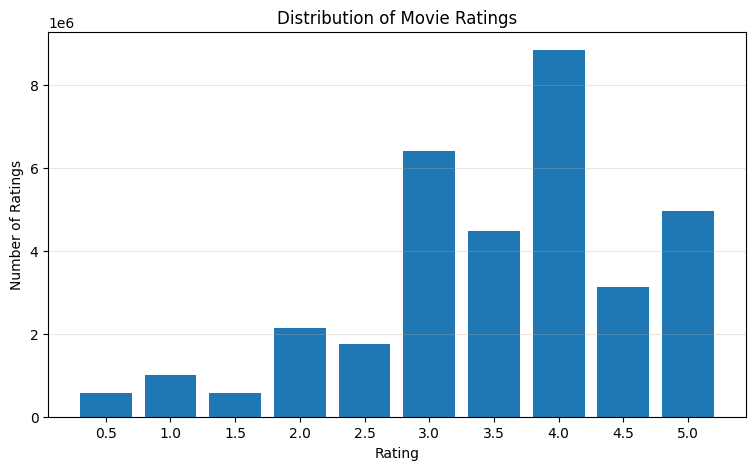

========== USER ACTIVITY ==========

Average ratings per user : 102.22
Minimum ratings by user : 1
Maximum ratings by user : 33332
Median ratings per user : 31.0

========== MOVIE ACTIVITY ==========

Average ratings per movie : 406.45
Minimum ratings per movie : 1
Maximum ratings per movie : 122296
Median ratings per movie : 5.0

========== TOP 10 MOST RATED MOVIES ==========



,title,rating_count
0,"Shawshank Redemption, The (1994)",122296
1,Forrest Gump (1994),113581
2,Pulp Fiction (1994),108756
3,"Matrix, The (1999)",107056
4,"Silence of the Lambs, The (1991)",101802
5,Star Wars: Episode IV - A New Hope (1977),97202
6,Fight Club (1999),86207
7,Schindler's List (1993),84232
8,Jurassic Park (1993),83026
9,Star Wars: Episode V - The Empire Strikes Back...,80200



========== DATASET SPARSITY ==========

Possible user-movie interactions : 27,550,028,025
Actual ratings                   : 33,832,162
Sparsity                          : 99.8772%


In [ ]:
# ============================================================
# STEP 6: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# ------------------------------------------------------------
# 1. Rating Distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

rating_counts = ratings_clean["rating"].value_counts().sort_index()

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")
plt.grid(axis="y", alpha=0.3)

plt.show()


# ------------------------------------------------------------
# 2. Number of Ratings per User
# ------------------------------------------------------------

ratings_per_user = ratings_clean.groupby("userId").size()

print("========== USER ACTIVITY ==========\n")
print("Average ratings per user :", round(ratings_per_user.mean(), 2))
print("Minimum ratings by user :", ratings_per_user.min())
print("Maximum ratings by user :", ratings_per_user.max())
print("Median ratings per user :", ratings_per_user.median())


# ------------------------------------------------------------
# 3. Number of Ratings per Movie
# ------------------------------------------------------------

ratings_per_movie = ratings_clean.groupby("movieId").size()

print("\n========== MOVIE ACTIVITY ==========\n")
print("Average ratings per movie :", round(ratings_per_movie.mean(), 2))
print("Minimum ratings per movie :", ratings_per_movie.min())
print("Maximum ratings per movie :", ratings_per_movie.max())
print("Median ratings per movie :", ratings_per_movie.median())


# ------------------------------------------------------------
# 4. Most Rated Movies
# ------------------------------------------------------------

most_rated = (
    ratings_per_movie
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

most_rated.columns = ["movieId", "rating_count"]

most_rated = most_rated.merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left"
)

print("\n========== TOP 10 MOST RATED MOVIES ==========\n")
display(most_rated[["title", "rating_count"]])


# ------------------------------------------------------------
# 5. Dataset Sparsity
# ------------------------------------------------------------

total_possible_interactions = (
    num_users * num_movies_rated
)

actual_interactions = len(ratings_clean)

sparsity = (
    1 - actual_interactions / total_possible_interactions
) * 100

print("\n========== DATASET SPARSITY ==========\n")
print("Possible user-movie interactions :",
      f"{total_possible_interactions:,}")

print("Actual ratings                   :",
      f"{actual_interactions:,}")

print("Sparsity                          :",
      f"{sparsity:.4f}%")

In [ ]:
# ============================================================
# STEP 7: TRAIN / TEST SPLIT
# ============================================================

# Split the cleaned ratings dataset
train_df, test_df = train_test_split(
    ratings_clean,
    test_size=0.20,
    random_state=42
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("========== TRAIN / TEST SPLIT ==========\n")

print("Total ratings :", len(ratings_clean))
print("Training data :", len(train_df))
print("Testing data  :", len(test_df))

print("\nTraining percentage:",
      round(len(train_df) / len(ratings_clean) * 100, 2), "%")

print("Testing percentage :",
      round(len(test_df) / len(ratings_clean) * 100, 2), "%")

print("\nTraining sample:")
display(train_df.head())

print("\nTesting sample:")
display(test_df.head())

========== TRAIN / TEST SPLIT ==========

Total ratings : 33832162
Training data : 27065729
Testing data  : 6766433

Training percentage: 80.0 %
Testing percentage : 20.0 %

Training sample:


,userId,movieId,rating
0,252136,2028,5.0
1,202354,8808,4.0
2,29826,4893,3.5
3,66306,1148,5.0
4,167689,97225,2.5



Testing sample:


,userId,movieId,rating
0,23474,8636,2.0
1,327932,480,2.0
2,32973,5481,0.5
3,174379,7325,3.5
4,197873,2467,4.5


In [ ]:
# ============================================================
# STEP 8: USER & MOVIE ID ENCODING FOR NCF
# ============================================================

# Create mappings from original IDs to consecutive integer indices
user_ids = train_df["userId"].unique()
movie_ids = train_df["movieId"].unique()

user_to_index = {
    user_id: index
    for index, user_id in enumerate(user_ids)
}

movie_to_index = {
    movie_id: index
    for index, movie_id in enumerate(movie_ids)
}

# Apply mappings to training data
train_df["user_idx"] = train_df["userId"].map(user_to_index)
train_df["movie_idx"] = train_df["movieId"].map(movie_to_index)

# Apply mappings to testing data
test_df["user_idx"] = test_df["userId"].map(user_to_index)
test_df["movie_idx"] = test_df["movieId"].map(movie_to_index)

# Check for users/movies that appear only in test data
test_unknown_users = test_df["user_idx"].isna().sum()
test_unknown_movies = test_df["movie_idx"].isna().sum()

print("========== NCF ENCODING ==========\n")

print("Number of encoded users  :", len(user_to_index))
print("Number of encoded movies :", len(movie_to_index))

print("\nUnknown users in test set :",
      test_unknown_users)

print("Unknown movies in test set:",
      test_unknown_movies)

print("\nTraining sample:")
display(
    train_df[["userId", "movieId", "rating",
              "user_idx", "movie_idx"]].head()
)

print("\nTesting sample:")
display(
    test_df[["userId", "movieId", "rating",
             "user_idx", "movie_idx"]].head()
)

========== NCF ENCODING ==========

Number of encoded users  : 328894
Number of encoded movies : 79145

Unknown users in test set : 2452
Unknown movies in test set: 4647

Training sample:


,userId,movieId,rating,user_idx,movie_idx
0,252136,2028,5.0,0,0
1,202354,8808,4.0,1,1
2,29826,4893,3.5,2,2
3,66306,1148,5.0,3,3
4,167689,97225,2.5,4,4



Testing sample:


,userId,movieId,rating,user_idx,movie_idx
0,23474,8636,2.0,56840.0,710.0
1,327932,480,2.0,105538.0,502.0
2,32973,5481,0.5,76628.0,1474.0
3,174379,7325,3.5,2824.0,2046.0
4,197873,2467,4.5,78531.0,2715.0


In [ ]:
# ============================================================
# STEP 9: PREPARE DATA FOR NCF
# ============================================================

# ------------------------------------------------------------
# 1. Remove test interactions with unseen users/movies
# ------------------------------------------------------------

test_ncf = test_df.dropna(
    subset=["user_idx", "movie_idx"]
).copy()

# ------------------------------------------------------------
# 2. Convert encoded IDs to memory-efficient integer types
# ------------------------------------------------------------

train_ncf_users = train_df["user_idx"].to_numpy(dtype=np.int32)
train_ncf_movies = train_df["movie_idx"].to_numpy(dtype=np.int32)
train_ncf_ratings = train_df["rating"].to_numpy(dtype=np.float32)

test_ncf_users = test_ncf["user_idx"].to_numpy(dtype=np.int32)
test_ncf_movies = test_ncf["movie_idx"].to_numpy(dtype=np.int32)
test_ncf_ratings = test_ncf["rating"].to_numpy(dtype=np.float32)

# ------------------------------------------------------------
# 3. Number of users and movies for embedding layers
# ------------------------------------------------------------

num_ncf_users = len(user_to_index)
num_ncf_movies = len(movie_to_index)

# ------------------------------------------------------------
# 4. Display information
# ------------------------------------------------------------

print("========== NCF DATA PREPARATION ==========\n")

print("Training interactions :", len(train_ncf_ratings))
print("Testing interactions  :", len(test_ncf_ratings))

print("\nRemoved test interactions due to unseen IDs:",
      len(test_df) - len(test_ncf))

print("\nNumber of users for NCF :", num_ncf_users)
print("Number of movies for NCF:", num_ncf_movies)

print("\nTraining arrays:")
print("Users  :", train_ncf_users.shape, train_ncf_users.dtype)
print("Movies :", train_ncf_movies.shape, train_ncf_movies.dtype)
print("Ratings:", train_ncf_ratings.shape, train_ncf_ratings.dtype)

print("\nTesting arrays:")
print("Users  :", test_ncf_users.shape, test_ncf_users.dtype)
print("Movies :", test_ncf_movies.shape, test_ncf_movies.dtype)
print("Ratings:", test_ncf_ratings.shape, test_ncf_ratings.dtype)

print("\nSample training data:")
print("User indices :", train_ncf_users[:5])
print("Movie indices:", train_ncf_movies[:5])
print("Ratings      :", train_ncf_ratings[:5])

print("\nSample testing data:")
print("User indices :", test_ncf_users[:5])
print("Movie indices:", test_ncf_movies[:5])
print("Ratings      :", test_ncf_ratings[:5])

========== NCF DATA PREPARATION ==========

Training interactions : 27065729
Testing interactions  : 6759335

Removed test interactions due to unseen IDs: 7098

Number of users for NCF : 328894
Number of movies for NCF: 79145

Training arrays:
Users  : (27065729,) int32
Movies : (27065729,) int32
Ratings: (27065729,) float32

Testing arrays:
Users  : (6759335,) int32
Movies : (6759335,) int32
Ratings: (6759335,) float32

Sample training data:
User indices : [0 1 2 3 4]
Movie indices: [0 1 2 3 4]
Ratings      : [5.  4.  3.5 5.  2.5]

Sample testing data:
User indices : [ 56840 105538  76628   2824  78531]
Movie indices: [ 710  502 1474 2046 2715]
Ratings      : [2.  2.  0.5 3.5 4.5]


In [ ]:
# ============================================================
# STEP 10: CHECK COLAB HARDWARE
# ============================================================

import tensorflow as tf
import psutil

print("========== HARDWARE INFORMATION ==========\n")

# CPU
print("CPU cores:", psutil.cpu_count(logical=True))

# RAM
ram = psutil.virtual_memory()
print("Total RAM :", round(ram.total / (1024**3), 2), "GB")
print("Available RAM:", round(ram.available / (1024**3), 2), "GB")

# GPU
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("\nGPU available: YES")
    for gpu in gpus:
        print("GPU:", gpu)
else:
    print("\nGPU available: NO")

# TensorFlow device check
print("\nTensorFlow version:", tf.__version__)

========== HARDWARE INFORMATION ==========

CPU cores: 2
Total RAM : 12.67 GB
Available RAM: 7.79 GB

GPU available: NO

TensorFlow version: 2.20.0


In [ ]:
# ============================================================
# STEP 11: CREATE TRAINING & EVALUATION SUBSETS
# Hardware-aware configuration for CPU-only Colab
# ============================================================

# Reproducibility
RANDOM_STATE = 42

# Number of interactions used for model training/evaluation
NCF_TRAIN_SIZE = 2_000_000
EVAL_SIZE = 500_000

# ------------------------------------------------------------
# Create training subset
# ------------------------------------------------------------

train_sample = train_df.sample(
    n=NCF_TRAIN_SIZE,
    random_state=RANDOM_STATE
).reset_index(drop=True)

# ------------------------------------------------------------
# Create evaluation subset
# ------------------------------------------------------------

test_sample = test_ncf.sample(
    n=EVAL_SIZE,
    random_state=RANDOM_STATE
).reset_index(drop=True)

# ------------------------------------------------------------
# Convert to NumPy arrays
# ------------------------------------------------------------

X_train_users = train_sample["user_idx"].astype("int32").to_numpy()
X_train_movies = train_sample["movie_idx"].astype("int32").to_numpy()
y_train = train_sample["rating"].astype("float32").to_numpy()

X_test_users = test_sample["user_idx"].astype("int32").to_numpy()
X_test_movies = test_sample["movie_idx"].astype("int32").to_numpy()
y_test = test_sample["rating"].astype("float32").to_numpy()

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("========== MODEL TRAINING CONFIGURATION ==========\n")

print("Complete MovieLens ratings :", f"{len(ratings_clean):,}")

print("\nTraining:")
print("Available training ratings :", f"{len(train_df):,}")
print("Selected training ratings  :", f"{len(train_sample):,}")

print("\nEvaluation:")
print("Available test ratings     :", f"{len(test_ncf):,}")
print("Selected test ratings      :", f"{len(test_sample):,}")

print("\nArray shapes:")
print("X_train_users  :", X_train_users.shape)
print("X_train_movies :", X_train_movies.shape)
print("y_train        :", y_train.shape)

print("X_test_users   :", X_test_users.shape)
print("X_test_movies  :", X_test_movies.shape)
print("y_test         :", y_test.shape)

print("\nRating range:")
print("Training:", y_train.min(), "to", y_train.max())
print("Testing :", y_test.min(), "to", y_test.max())

print("\nConfiguration ready for SVD and NCF.")

========== MODEL TRAINING CONFIGURATION ==========

Complete MovieLens ratings : 33,832,162

Training:
Available training ratings : 27,065,729
Selected training ratings  : 2,000,000

Evaluation:
Available test ratings     : 6,759,335
Selected test ratings      : 500,000

Array shapes:
X_train_users  : (2000000,)
X_train_movies : (2000000,)
y_train        : (2000000,)
X_test_users   : (500000,)
X_test_movies  : (500000,)
y_test         : (500000,)

Rating range:
Training: 0.5 to 5.0
Testing : 0.5 to 5.0

Configuration ready for SVD and NCF.


In [ ]:
# ============================================================
# STEP 12: SVD COLLABORATIVE FILTERING MODEL
# ============================================================

from surprise import SVD, Dataset, Reader

# ------------------------------------------------------------
# Prepare data for Surprise
# ------------------------------------------------------------

svd_train_data = train_sample[["userId", "movieId", "rating"]].copy()

reader = Reader(
    rating_scale=(0.5, 5.0)
)

svd_dataset = Dataset.load_from_df(
    svd_train_data,
    reader
)

svd_trainset = svd_dataset.build_full_trainset()

# ------------------------------------------------------------
# Create SVD model
# ------------------------------------------------------------

svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("Training SVD model...")
print("Please wait; CPU training may take some time.\n")

svd_model.fit(svd_trainset)

print("SVD training completed successfully!")


Training SVD model...
Please wait; CPU training may take some time.

SVD training completed successfully!


In [ ]:
# ============================================================
# STEP 13: SVD MODEL EVALUATION
# ============================================================

print("Evaluating SVD model...\n")

# Predict ratings for the 500,000 test interactions
svd_predictions = []

for user_id, movie_id, actual_rating in zip(
    test_sample["userId"],
    test_sample["movieId"],
    test_sample["rating"]
):
    prediction = svd_model.predict(
        int(user_id),
        int(movie_id)
    )

    svd_predictions.append(prediction.est)

# Convert predictions to NumPy array
svd_predictions = np.array(
    svd_predictions,
    dtype=np.float32
)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

svd_mse = mean_squared_error(
    y_test,
    svd_predictions
)

svd_rmse = np.sqrt(svd_mse)

svd_mae = mean_absolute_error(
    y_test,
    svd_predictions
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("========== SVD PERFORMANCE ==========\n")

print(f"MSE  : {svd_mse:.4f}")
print(f"RMSE : {svd_rmse:.4f}")
print(f"MAE  : {svd_mae:.4f}")

print("\nEvaluation completed successfully!")

Evaluating SVD model...

========== SVD PERFORMANCE ==========

MSE  : 0.8323
RMSE : 0.9123
MAE  : 0.6989

Evaluation completed successfully!


In [ ]:
# ============================================================
# STEP 14: BUILD NEURAL COLLABORATIVE FILTERING (NCF) MODEL
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# ------------------------------------------------------------
# NCF Configuration
# ------------------------------------------------------------

EMBEDDING_SIZE = 32

# ------------------------------------------------------------
# Input layers
# ------------------------------------------------------------

user_input = keras.Input(
    shape=(1,),
    name="user_input"
)

movie_input = keras.Input(
    shape=(1,),
    name="movie_input"
)

# ------------------------------------------------------------
# User & Movie Embeddings
# ------------------------------------------------------------

user_embedding_gmf = layers.Embedding(
    input_dim=num_ncf_users,
    output_dim=EMBEDDING_SIZE,
    name="user_embedding_gmf"
)(user_input)

movie_embedding_gmf = layers.Embedding(
    input_dim=num_ncf_movies,
    output_dim=EMBEDDING_SIZE,
    name="movie_embedding_gmf"
)(movie_input)

# Flatten embeddings
user_gmf = layers.Flatten()(user_embedding_gmf)
movie_gmf = layers.Flatten()(movie_embedding_gmf)

# ------------------------------------------------------------
# GMF Branch
# ------------------------------------------------------------

gmf_output = layers.Multiply()(
    [user_gmf, movie_gmf]
)

# ------------------------------------------------------------
# MLP Branch
# ------------------------------------------------------------

user_embedding_mlp = layers.Embedding(
    input_dim=num_ncf_users,
    output_dim=EMBEDDING_SIZE,
    name="user_embedding_mlp"
)(user_input)

movie_embedding_mlp = layers.Embedding(
    input_dim=num_ncf_movies,
    output_dim=EMBEDDING_SIZE,
    name="movie_embedding_mlp"
)(movie_input)

user_mlp = layers.Flatten()(user_embedding_mlp)
movie_mlp = layers.Flatten()(movie_embedding_mlp)

# Concatenate user and movie embeddings
mlp_input = layers.Concatenate()(
    [user_mlp, movie_mlp]
)

# Neural network layers
mlp_output = layers.Dense(
    64,
    activation="relu"
)(mlp_input)

mlp_output = layers.Dropout(0.2)(mlp_output)

mlp_output = layers.Dense(
    32,
    activation="relu"
)(mlp_output)

# ------------------------------------------------------------
# Combine GMF + MLP
# ------------------------------------------------------------

combined = layers.Concatenate()(
    [gmf_output, mlp_output]
)

# Final prediction layer
output = layers.Dense(
    1,
    activation="linear",
    name="rating_prediction"
)(combined)

# ------------------------------------------------------------
# Create Model
# ------------------------------------------------------------

ncf_model = keras.Model(
    inputs=[user_input, movie_input],
    outputs=output,
    name="Neural_Collaborative_Filtering"
)

# ------------------------------------------------------------
# Compile Model
# ------------------------------------------------------------

ncf_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

# ------------------------------------------------------------
# Display Model
# ------------------------------------------------------------

ncf_model.summary()

Model: "Neural_Collaborative_Filtering"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding_mlp  │ (None, 1, 32)     │ 10,524,608 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding_mlp │ (None, 1, 32)     │  2,532,640 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 32)        │          0 │ user_embedding_m… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 32)        │          0 │ movie_embedding_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding_gmf  │ (None, 1, 32)     │ 10,524,608 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding_gmf │ (None, 1, 32)     │  2,532,640 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ user_embedding_g… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ movie_embedding_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 32)        │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64)        │          0 │ multiply[0][0],   │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_prediction   │ (None, 1)         │         65 │ concatenate_1[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,120,801 (99.64 MB)

 Trainable params: 26,120,801 (99.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# STEP 15: CREATE NCF TRAINING PIPELINE
# ============================================================

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

BATCH_SIZE = 4096
EPOCHS = 8

print("========== NCF TRAINING CONFIGURATION ==========\n")
print("Training samples :", len(y_train))
print("Validation samples:", len(y_test))
print("Batch size       :", BATCH_SIZE)
print("Maximum epochs   :", EPOCHS)

# ------------------------------------------------------------
# Create TensorFlow datasets
# ------------------------------------------------------------

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            "user_input": X_train_users,
            "movie_input": X_train_movies
        },
        y_train
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            "user_input": X_test_users,
            "movie_input": X_test_movies
        },
        y_test
    )
)

# Shuffle and batch training data
train_dataset = (
    train_dataset
    .shuffle(
        buffer_size=100000,
        seed=42
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Batch test data
test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

print("\nTensorFlow datasets created successfully!")
print("Early stopping enabled.")

========== NCF TRAINING CONFIGURATION ==========

Training samples : 2000000
Validation samples: 500000
Batch size       : 4096
Maximum epochs   : 8

TensorFlow datasets created successfully!
Early stopping enabled.


In [ ]:
# ============================================================
# STEP 16: TRAIN NCF MODEL
# ============================================================

print("========== STARTING NCF TRAINING ==========\n")
print("Training on 2,000,000 interactions...")
print("Validation on 500,000 interactions...")
print("Please wait...\n")

history = ncf_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

print("\n========== NCF TRAINING COMPLETED ==========")

========== STARTING NCF TRAINING ==========

Training on 2,000,000 interactions...
Validation on 500,000 interactions...
Please wait...

Epoch 1/8
489/489 ━━━━━━━━━━━━━━━━━━━━ 169s 336ms/step - loss: 2.0357 - mae: 1.0317 - val_loss: 0.8301 - val_mae: 0.6990
Epoch 2/8
489/489 ━━━━━━━━━━━━━━━━━━━━ 199s 331ms/step - loss: 0.7932 - mae: 0.6857 - val_loss: 0.8177 - val_mae: 0.6912
Epoch 3/8
489/489 ━━━━━━━━━━━━━━━━━━━━ 203s 334ms/step - loss: 0.5897 - mae: 0.5794 - val_loss: 0.8587 - val_mae: 0.7103
Epoch 4/8
489/489 ━━━━━━━━━━━━━━━━━━━━ 164s 334ms/step - loss: 0.3566 - mae: 0.4426 - val_loss: 0.9149 - val_mae: 0.7366
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.

========== NCF TRAINING COMPLETED ==========


In [ ]:
# ============================================================
# STEP 17: FINAL NCF MODEL EVALUATION
# ============================================================

print("Evaluating final NCF model...\n")

# Predict ratings on the test set
ncf_predictions = ncf_model.predict(
    test_dataset,
    verbose=1
).flatten()

# Make sure predictions are float32
ncf_predictions = ncf_predictions.astype(np.float32)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

ncf_mse = mean_squared_error(
    y_test,
    ncf_predictions
)

ncf_rmse = np.sqrt(ncf_mse)

ncf_mae = mean_absolute_error(
    y_test,
    ncf_predictions
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n========== NCF PERFORMANCE ==========\n")

print(f"MSE  : {ncf_mse:.4f}")
print(f"RMSE : {ncf_rmse:.4f}")
print(f"MAE  : {ncf_mae:.4f}")

print("\nEvaluation completed successfully!")

Evaluating final NCF model...

123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step

========== NCF PERFORMANCE ==========

MSE  : 0.8177
RMSE : 0.9043
MAE  : 0.6912

Evaluation completed successfully!


In [ ]:
# ============================================================
# STEP 18: SVD vs NCF MODEL COMPARISON
# ============================================================

# Create comparison dataframe
comparison = pd.DataFrame({
    "Model": ["SVD", "NCF"],
    "MSE": [svd_mse, ncf_mse],
    "RMSE": [svd_rmse, ncf_rmse],
    "MAE": [svd_mae, ncf_mae]
})

print("========== MODEL PERFORMANCE COMPARISON ==========\n")

display(
    comparison.style.format({
        "MSE": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Calculate NCF improvement
# ------------------------------------------------------------

mse_improvement = (
    (svd_mse - ncf_mse) / svd_mse
) * 100

rmse_improvement = (
    (svd_rmse - ncf_rmse) / svd_rmse
) * 100

mae_improvement = (
    (svd_mae - ncf_mae) / svd_mae
) * 100

print("\n========== NCF IMPROVEMENT OVER SVD ==========\n")

print(f"MSE improvement  : {mse_improvement:.2f}%")
print(f"RMSE improvement : {rmse_improvement:.2f}%")
print(f"MAE improvement  : {mae_improvement:.2f}%")

# ------------------------------------------------------------
# Determine best model
# ------------------------------------------------------------

best_model = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

print("\nBest model based on RMSE:", best_model)

========== MODEL PERFORMANCE COMPARISON ==========



,Model,MSE,RMSE,MAE
0,SVD,0.8323,0.9123,0.6989
1,NCF,0.8177,0.9043,0.6912



========== NCF IMPROVEMENT OVER SVD ==========

MSE improvement  : 1.76%
RMSE improvement : 0.88%
MAE improvement  : 1.09%

Best model based on RMSE: NCF


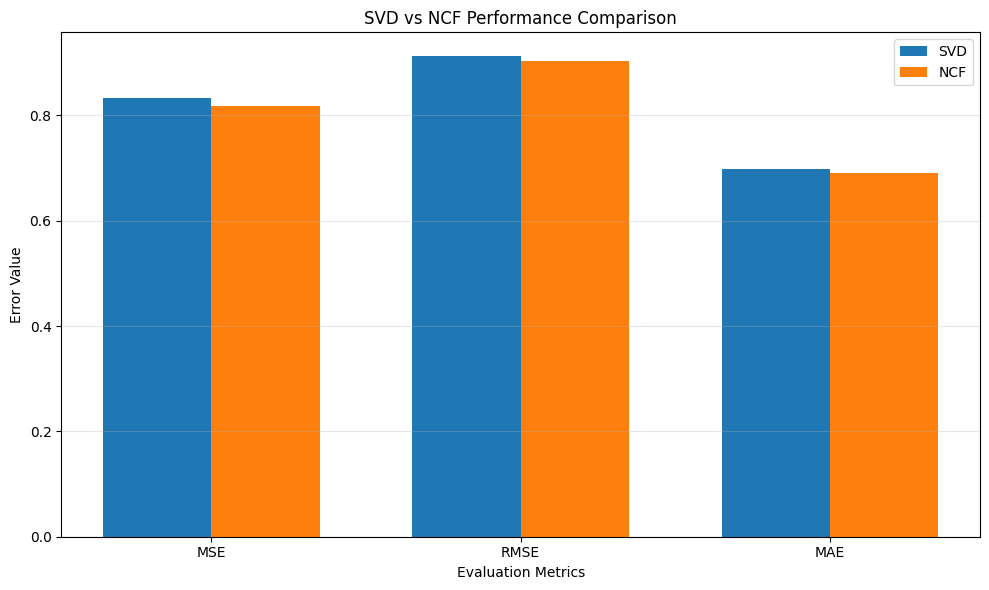

In [ ]:
# ============================================================
# STEP 19: MODEL PERFORMANCE VISUALIZATION
# ============================================================

metrics = ["MSE", "RMSE", "MAE"]

svd_values = [
    svd_mse,
    svd_rmse,
    svd_mae
]

ncf_values = [
    ncf_mse,
    ncf_rmse,
    ncf_mae
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    svd_values,
    width,
    label="SVD"
)

plt.bar(
    x + width / 2,
    ncf_values,
    width,
    label="NCF"
)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Error Value")
plt.title("SVD vs NCF Performance Comparison")

plt.xticks(x, metrics)
plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 20: NCF PERSONALIZED RECOMMENDATION ENGINE
# ============================================================

def recommend_movies(user_id, top_n=10):
    """
    Generate personalized movie recommendations
    for a given user using the trained NCF model.
    """

    # Check whether the user exists in training data
    if user_id not in user_to_index:
        print(f"User {user_id} was not found in the training data.")
        print("Please enter a user ID that exists in the training dataset.")
        return None

    # Convert original user ID to encoded index
    user_idx = user_to_index[user_id]

    # Find movies already rated by the user
    rated_movies = set(
        ratings_clean.loc[
            ratings_clean["userId"] == user_id,
            "movieId"
        ]
    )

    # Candidate movies = movies available to NCF
    candidate_movie_ids = [
        movie_id
        for movie_id in movie_ids
        if movie_id not in rated_movies
    ]

    # Convert movie IDs to encoded indices
    candidate_movie_indices = np.array(
        [movie_to_index[movie_id] for movie_id in candidate_movie_ids],
        dtype=np.int32
    )

    # Create user array
    user_indices = np.full(
        len(candidate_movie_indices),
        user_idx,
        dtype=np.int32
    )

    # Predict ratings
    predictions = ncf_model.predict(
        {
            "user_input": user_indices,
            "movie_input": candidate_movie_indices
        },
        batch_size=4096,
        verbose=0
    ).flatten()

    # Create recommendation dataframe
    recommendations = pd.DataFrame({
        "movieId": candidate_movie_ids,
        "predicted_rating": predictions
    })

    # Sort by predicted rating
    recommendations = recommendations.sort_values(
        "predicted_rating",
        ascending=False
    ).head(top_n)

    # Add movie titles and genres
    recommendations = recommendations.merge(
        movies[["movieId", "title", "genres"]],
        on="movieId",
        how="left"
    )

    # Reorder columns
    recommendations = recommendations[
        ["movieId", "title", "genres", "predicted_rating"]
    ]

    # Reset index
    recommendations.reset_index(drop=True, inplace=True)

    # Round predicted ratings
    recommendations["predicted_rating"] = (
        recommendations["predicted_rating"].round(2)
    )

    return recommendations


print("Recommendation engine created successfully!")

Recommendation engine created successfully!


In [ ]:
# ============================================================
# STEP 21: GENERATE PERSONALIZED RECOMMENDATIONS
# ============================================================

# Select a user with a reasonable rating history
user_rating_counts = (
    ratings_clean
    .groupby("userId")
    .size()
    .sort_values(ascending=False)
)

# Select a user from the top active users
test_user_id = user_rating_counts.index[0]

print("Selected User ID:", test_user_id)
print(
    "Number of ratings by this user:",
    user_rating_counts.loc[test_user_id]
)

# Generate Top-10 recommendations
recommendations = recommend_movies(
    user_id=test_user_id,
    top_n=10
)

print("\n========== TOP 10 PERSONALIZED RECOMMENDATIONS ==========\n")

display(recommendations)

Selected User ID: 189614
Number of ratings by this user: 33332

========== TOP 10 PERSONALIZED RECOMMENDATIONS ==========



,movieId,title,genres,predicted_rating
0,198185,Twin Peaks (1989),Drama|Mystery,4.17
1,136469,Larry David: Curb Your Enthusiasm (1999),Comedy,4.15
2,720,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,4.08
3,179135,Blue Planet II (2017),Documentary,4.01
4,228099,Firefly (2002),Action|Adventure|Sci-Fi|Western,4.01
5,171749,Death Note: Desu nôto (2006–2007),(no genres listed),3.94
6,202749,Portrait of a Lady on Fire (2019),Drama|Romance,3.92
7,170355,Mulholland Dr. (1999),Drama|Mystery|Romance,3.92
8,86345,Louis C.K.: Hilarious (2010),Comedy,3.90
9,286897,Spider-Man: Across the Spider-Verse (2023),Action|Adventure|Animation|Sci-Fi,3.88


In [ ]:
# ============================================================
# STEP 22: TEST RECOMMENDATION QUALITY
# ============================================================

print("========== RECOMMENDATION QUALITY TEST ==========\n")

# ------------------------------------------------------------
# 1. Check number of recommendations
# ------------------------------------------------------------

print("Number of recommendations:", len(recommendations))

# ------------------------------------------------------------
# 2. Check for duplicate movies
# ------------------------------------------------------------

duplicate_movies = recommendations["movieId"].duplicated().sum()

print("Duplicate recommendations:", duplicate_movies)

# ------------------------------------------------------------
# 3. Check whether recommended movies were already rated
# ------------------------------------------------------------

user_rated_movies = set(
    ratings_clean.loc[
        ratings_clean["userId"] == test_user_id,
        "movieId"
    ]
)

recommended_movies = set(
    recommendations["movieId"]
)

already_rated = recommended_movies.intersection(
    user_rated_movies
)

print("Already-rated recommended movies:",
      len(already_rated))

# ------------------------------------------------------------
# 4. Check predicted rating range
# ------------------------------------------------------------

print(
    "Minimum predicted rating:",
    recommendations["predicted_rating"].min()
)

print(
    "Maximum predicted rating:",
    recommendations["predicted_rating"].max()
)

# ------------------------------------------------------------
# 5. Final validation
# ------------------------------------------------------------

if (
    duplicate_movies == 0
    and len(already_rated) == 0
    and len(recommendations) == 10
):
    print("\nRecommendation quality test: PASSED")
else:
    print("\nRecommendation quality test: CHECK REQUIRED")

# ------------------------------------------------------------
# 6. Display user's rating history summary
# ------------------------------------------------------------

user_history = ratings_clean[
    ratings_clean["userId"] == test_user_id
]

print("\n========== USER PROFILE ==========\n")

print("User ID:", test_user_id)
print("Total ratings:", len(user_history))
print("Average rating:",
      round(user_history["rating"].mean(), 2))

print("\nRating distribution:")
display(
    user_history["rating"]
    .value_counts()
    .sort_index()
)

========== RECOMMENDATION QUALITY TEST ==========

Number of recommendations: 10
Duplicate recommendations: 0
Already-rated recommended movies: 0
Minimum predicted rating: 3.880000114440918
Maximum predicted rating: 4.170000076293945

Recommendation quality test: PASSED

========== USER PROFILE ==========

User ID: 189614
Total ratings: 33332
Average rating: 3.08

Rating distribution:


,count
rating,
0.5,186
1.0,335
1.5,785
2.0,2304
2.5,6165
3.0,10359
3.5,8346
4.0,3070
4.5,1029


In [ ]:
# ============================================================
# STEP 23: TEST RECOMMENDATIONS FOR MULTIPLE USERS
# ============================================================

print("========== MULTI-USER RECOMMENDATION TEST ==========\n")

# Get users with their rating counts
user_activity = (
    ratings_clean
    .groupby("userId")
    .size()
    .sort_values()
)

# Select users from different activity levels
candidate_users = [
    user_activity.index[len(user_activity) // 4],
    user_activity.index[len(user_activity) // 2],
    user_activity.index[(3 * len(user_activity)) // 4],
    user_activity.index[-1]
]

for user_id in candidate_users:

    print("\n" + "=" * 60)
    print("User ID:", user_id)

    rating_count = user_activity.loc[user_id]

    print("Number of ratings:", rating_count)

    # Generate recommendations
    user_recommendations = recommend_movies(
        user_id=int(user_id),
        top_n=5
    )

    if user_recommendations is not None:

        print("\nTop 5 Recommendations:")

        display(
            user_recommendations[
                ["title", "genres", "predicted_rating"]
            ]
        )

        # Check for already-rated movies
        rated_movies = set(
            ratings_clean.loc[
                ratings_clean["userId"] == user_id,
                "movieId"
            ]
        )

        recommended_movie_ids = set(
            user_recommendations["movieId"]
        )

        overlap = rated_movies.intersection(
            recommended_movie_ids
        )

        print(
            "Already-rated recommendations:",
            len(overlap)
        )

print("\n" + "=" * 60)
print("Multi-user testing completed successfully!")


========== MULTI-USER RECOMMENDATION TEST ==========


User ID: 255471
Number of ratings: 15

Top 5 Recommendations:


,title,genres,predicted_rating
0,Planet Earth (2006),Documentary,4.44
1,Night and Fog (Nuit et brouillard) (1955),Crime|Documentary|War,4.39
2,Twin Peaks (1989),Drama|Mystery,4.35
3,Planet Earth II (2016),Documentary,4.34
4,To Live (Huozhe) (1994),Drama,4.33


Already-rated recommendations: 0

User ID: 249306
Number of ratings: 31

Top 5 Recommendations:


,title,genres,predicted_rating
0,Planet Earth (2006),Documentary,4.56
1,Night and Fog (Nuit et brouillard) (1955),Crime|Documentary|War,4.50
2,Planet Earth II (2016),Documentary,4.47
3,Twin Peaks (1989),Drama|Mystery,4.46
4,To Live (Huozhe) (1994),Drama,4.43


Already-rated recommendations: 0

User ID: 229976
Number of ratings: 98

Top 5 Recommendations:


,title,genres,predicted_rating
0,Planet Earth (2006),Documentary,4.27
1,Night and Fog (Nuit et brouillard) (1955),Crime|Documentary|War,4.20
2,Planet Earth II (2016),Documentary,4.20
3,Twin Peaks (1989),Drama|Mystery,4.18
4,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,4.13


Already-rated recommendations: 0

User ID: 189614
Number of ratings: 33332

Top 5 Recommendations:


,title,genres,predicted_rating
0,Twin Peaks (1989),Drama|Mystery,4.17
1,Larry David: Curb Your Enthusiasm (1999),Comedy,4.15
2,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,4.08
3,Blue Planet II (2017),Documentary,4.01
4,Firefly (2002),Action|Adventure|Sci-Fi|Western,4.01


Already-rated recommendations: 0

Multi-user testing completed successfully!


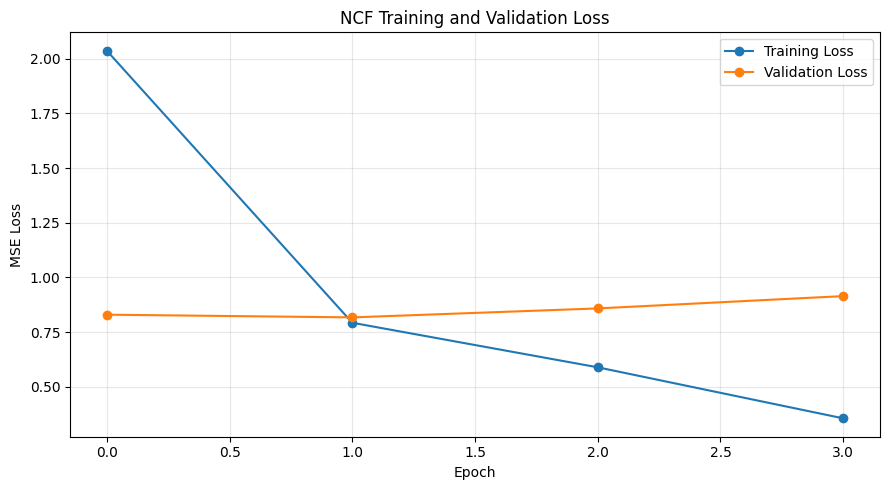

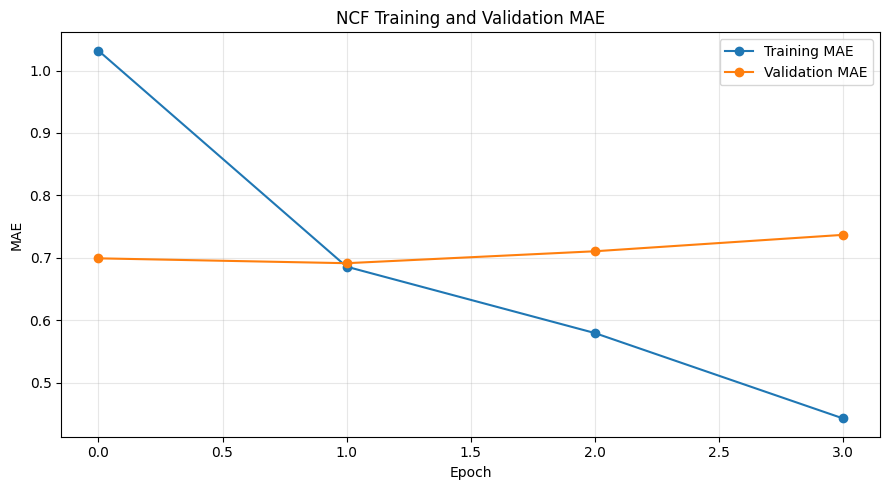

In [ ]:
# ============================================================
# STEP 24: NCF TRAINING HISTORY VISUALIZATION
# ============================================================

# Get training history
history_dict = history.history

# ------------------------------------------------------------
# Plot Loss
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    history_dict["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_dict["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("NCF Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot MAE
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    history_dict["mae"],
    marker="o",
    label="Training MAE"
)

plt.plot(
    history_dict["val_mae"],
    marker="o",
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("NCF Training and Validation MAE")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 25: INTERACTIVE RECOMMENDATION SYSTEM
# ============================================================

def run_recommender():
    print("=" * 60)
    print("       MOVIE RECOMMENDATION SYSTEM")
    print("       Neural Collaborative Filtering")
    print("=" * 60)

    # --------------------------------------------------------
    # Get User ID
    # --------------------------------------------------------

    try:
        user_id = int(input("\nEnter User ID: "))

    except ValueError:
        print("Invalid User ID. Please enter a number.")
        return

    # --------------------------------------------------------
    # Check user
    # --------------------------------------------------------

    if user_id not in user_to_index:
        print(f"\nUser {user_id} is not available in the trained model.")
        print("Please enter a valid User ID.")
        return

    # --------------------------------------------------------
    # Get number of recommendations
    # --------------------------------------------------------

    try:
        top_n = int(
            input("How many movies do you want? ")
        )

    except ValueError:
        print("Invalid number.")
        return

    if top_n <= 0:
        print("Number of recommendations must be greater than 0.")
        return

    # --------------------------------------------------------
    # Generate recommendations
    # --------------------------------------------------------

    print("\nGenerating personalized recommendations...")
    print("Please wait...\n")

    result = recommend_movies(
        user_id=user_id,
        top_n=top_n
    )

    # --------------------------------------------------------
    # Display results
    # --------------------------------------------------------

    if result is not None:

        print("=" * 60)
        print(f"TOP {top_n} RECOMMENDATIONS FOR USER {user_id}")
        print("=" * 60)

        display(
            result.style.format({
                "predicted_rating": "{:.2f}"
            })
        )

        print("\nRecommendation generation completed!")


# Run the recommender
run_recommender()

       MOVIE RECOMMENDATION SYSTEM
       Neural Collaborative Filtering

Enter User ID: 1
How many movies do you want? 5

Generating personalized recommendations...
Please wait...

TOP 5 RECOMMENDATIONS FOR USER 1


,movieId,title,genres,predicted_rating
0,159817,Planet Earth (2006),Documentary,4.62
1,26003,Night and Fog (Nuit et brouillard) (1955),Crime|Documentary|War,4.57
2,171011,Planet Earth II (2016),Documentary,4.55
3,198185,Twin Peaks (1989),Drama|Mystery,4.52
4,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.49



Recommendation generation completed!


In [ ]:
# ============================================================
# STEP 26: IMPROVED RECOMMENDATION RANKING
# ============================================================

def recommend_movies_improved(user_id, top_n=10, min_ratings=20):
    """
    Generate personalized recommendations using NCF,
    while filtering out extremely low-popularity movies.
    """

    # Check user
    if user_id not in user_to_index:
        print(f"User {user_id} was not found in the training data.")
        return None

    # Original user ID → encoded index
    user_idx = user_to_index[user_id]

    # Movies already rated by the user
    rated_movies = set(
        ratings_clean.loc[
            ratings_clean["userId"] == user_id,
            "movieId"
        ]
    )

    # --------------------------------------------------------
    # Calculate movie popularity
    # --------------------------------------------------------

    movie_rating_counts = (
        ratings_clean
        .groupby("movieId")
        .size()
    )

    # Movies with enough ratings
    popular_movies = set(
        movie_rating_counts[
            movie_rating_counts >= min_ratings
        ].index
    )

    # Candidate movies:
    # 1. Available to NCF
    # 2. Not already rated
    # 3. Have sufficient rating history
    candidate_movie_ids = [
        movie_id
        for movie_id in movie_ids
        if (
            movie_id not in rated_movies
            and movie_id in popular_movies
        )
    ]

    if len(candidate_movie_ids) == 0:
        print("No suitable candidate movies found.")
        return None

    # --------------------------------------------------------
    # Convert movie IDs to encoded indices
    # --------------------------------------------------------

    candidate_movie_indices = np.array(
        [
            movie_to_index[movie_id]
            for movie_id in candidate_movie_ids
        ],
        dtype=np.int32
    )

    user_indices = np.full(
        len(candidate_movie_indices),
        user_idx,
        dtype=np.int32
    )

    # --------------------------------------------------------
    # Predict ratings using NCF
    # --------------------------------------------------------

    predictions = ncf_model.predict(
        {
            "user_input": user_indices,
            "movie_input": candidate_movie_indices
        },
        batch_size=4096,
        verbose=0
    ).flatten()

    # --------------------------------------------------------
    # Create recommendation dataframe
    # --------------------------------------------------------

    recommendations = pd.DataFrame({
        "movieId": candidate_movie_ids,
        "predicted_rating": predictions
    })

    # Add popularity
    recommendations["rating_count"] = (
        recommendations["movieId"]
        .map(movie_rating_counts)
    )

    # Sort by predicted rating
    recommendations = (
        recommendations
        .sort_values(
            "predicted_rating",
            ascending=False
        )
        .head(top_n)
    )

    # Add movie information
    recommendations = recommendations.merge(
        movies[["movieId", "title", "genres"]],
        on="movieId",
        how="left"
    )

    # Arrange columns
    recommendations = recommendations[
        [
            "movieId",
            "title",
            "genres",
            "predicted_rating",
            "rating_count"
        ]
    ]

    recommendations.reset_index(
        drop=True,
        inplace=True
    )

    # Round values
    recommendations["predicted_rating"] = (
        recommendations["predicted_rating"].round(2)
    )

    return recommendations


print("Improved recommendation engine created successfully!")

Improved recommendation engine created successfully!


In [ ]:
# ============================================================
# STEP 27: TEST IMPROVED RECOMMENDATION ENGINE
# ============================================================

user_id = 1

print("=" * 65)
print(f"IMPROVED TOP 10 RECOMMENDATIONS FOR USER {user_id}")
print("=" * 65)

improved_recommendations = recommend_movies_improved(
    user_id=user_id,
    top_n=10,
    min_ratings=20
)

display(improved_recommendations)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

rated_movies = set(
    ratings_clean.loc[
        ratings_clean["userId"] == user_id,
        "movieId"
    ]
)

recommended_movies = set(
    improved_recommendations["movieId"]
)

already_rated = recommended_movies.intersection(
    rated_movies
)

print("\n========== VALIDATION ==========")

print(
    "Number of recommendations:",
    len(improved_recommendations)
)

print(
    "Already-rated movies:",
    len(already_rated)
)

print(
    "Minimum rating count:",
    improved_recommendations["rating_count"].min()
)

print(
    "Maximum predicted rating:",
    improved_recommendations["predicted_rating"].max()
)

if len(already_rated) == 0:
    print("\nRecommendation validation: PASSED")
else:
    print("\nRecommendation validation: FAILED")

IMPROVED TOP 10 RECOMMENDATIONS FOR USER 1


,movieId,title,genres,predicted_rating,rating_count
0,159817,Planet Earth (2006),Documentary,4.62,3015
1,26003,Night and Fog (Nuit et brouillard) (1955),Crime|Documentary|War,4.57,604
2,171011,Planet Earth II (2016),Documentary,4.55,2041
3,198185,Twin Peaks (1989),Drama|Mystery,4.52,1132
4,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.49,122296
5,326,To Live (Huozhe) (1994),Drama,4.49,1572
6,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,4.48,9627
7,858,"Godfather, The (1972)",Crime|Drama,4.44,75004
8,8199,Ugetsu (Ugetsu monogatari) (1953),Drama|Thriller,4.43,674
9,136469,Larry David: Curb Your Enthusiasm (1999),Comedy,4.42,475



========== VALIDATION ==========
Number of recommendations: 10
Already-rated movies: 0
Minimum rating count: 475
Maximum predicted rating: 4.619999885559082

Recommendation validation: PASSED


In [ ]:
# ============================================================
# STEP 28: TOP-N RECOMMENDATION EVALUATION
# Precision@10, Recall@10 and Hit Rate@10
# ============================================================

TOP_N = 10
MIN_RELEVANT_RATING = 4.0
NUM_EVAL_USERS = 50

print("========== TOP-N EVALUATION ==========\n")

# ------------------------------------------------------------
# Select users having at least one relevant test rating
# ------------------------------------------------------------

test_relevant = test_sample[
    test_sample["rating"] >= MIN_RELEVANT_RATING
]

eligible_users = (
    test_relevant["userId"]
    .unique()
)

# Use a fixed random sample of users
rng = np.random.default_rng(42)

if len(eligible_users) > NUM_EVAL_USERS:
    evaluation_users = rng.choice(
        eligible_users,
        size=NUM_EVAL_USERS,
        replace=False
    )
else:
    evaluation_users = eligible_users

print("Relevant rating threshold :", MIN_RELEVANT_RATING)
print("Users evaluated            :", len(evaluation_users))
print("Top-N                      :", TOP_N)

# ------------------------------------------------------------
# Store evaluation results
# ------------------------------------------------------------

precision_scores = []
recall_scores = []
hit_scores = []

# ------------------------------------------------------------
# Evaluate each user
# ------------------------------------------------------------

for i, user_id in enumerate(evaluation_users):

    # Ground-truth relevant movies
    relevant_movies = set(
        test_sample.loc[
            (test_sample["userId"] == user_id) &
            (test_sample["rating"] >= MIN_RELEVANT_RATING),
            "movieId"
        ]
    )

    if len(relevant_movies) == 0:
        continue

    # Movies already rated by the user
    rated_movies = set(
        ratings_clean.loc[
            ratings_clean["userId"] == user_id,
            "movieId"
        ]
    )

    # Candidate movies available to NCF
    candidate_movie_ids = [
        movie_id
        for movie_id in movie_ids
        if movie_id not in rated_movies
    ]

    # Convert movie IDs to encoded indices
    candidate_movie_indices = np.array(
        [
            movie_to_index[movie_id]
            for movie_id in candidate_movie_ids
        ],
        dtype=np.int32
    )

    # User indices
    user_indices = np.full(
        len(candidate_movie_indices),
        user_to_index[user_id],
        dtype=np.int32
    )

    # NCF predictions
    predictions = ncf_model.predict(
        {
            "user_input": user_indices,
            "movie_input": candidate_movie_indices
        },
        batch_size=4096,
        verbose=0
    ).flatten()

    # Get Top-N movie indices
    top_indices = np.argsort(
        predictions
    )[-TOP_N:][::-1]

    top_movies = {
        candidate_movie_ids[index]
        for index in top_indices
    }

    # Relevant recommendations
    recommended_relevant = (
        top_movies.intersection(relevant_movies)
    )

    # Precision@10
    precision = (
        len(recommended_relevant) / TOP_N
    )

    # Recall@10
    recall = (
        len(recommended_relevant) /
        len(relevant_movies)
    )

    # Hit Rate@10
    hit = 1 if len(recommended_relevant) > 0 else 0

    precision_scores.append(precision)
    recall_scores.append(recall)
    hit_scores.append(hit)

    if (i + 1) % 10 == 0:
        print(
            f"Evaluated {i + 1}/{len(evaluation_users)} users"
        )

# ------------------------------------------------------------
# Calculate final metrics
# ------------------------------------------------------------

precision_at_10 = np.mean(precision_scores)
recall_at_10 = np.mean(recall_scores)
hit_rate_at_10 = np.mean(hit_scores)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n========== TOP-N RESULTS ==========\n")

print(f"Precision@10 : {precision_at_10:.4f}")
print(f"Recall@10    : {recall_at_10:.4f}")
print(f"Hit Rate@10  : {hit_rate_at_10:.4f}")

print("\nTop-N evaluation completed successfully!")

========== TOP-N EVALUATION ==========

Relevant rating threshold : 4.0
Users evaluated            : 50
Top-N                      : 10
Evaluated 10/50 users
Evaluated 20/50 users
Evaluated 30/50 users
Evaluated 40/50 users
Evaluated 50/50 users

========== TOP-N RESULTS ==========

Precision@10 : 0.0000
Recall@10    : 0.0000
Hit Rate@10  : 0.0000

Top-N evaluation completed successfully!


In [ ]:
# ============================================================
# STEP 28: CORRECT TOP-N EVALUATION
# ============================================================

TOP_N = 10
RELEVANT_THRESHOLD = 4.0
NUM_EVAL_USERS = 50

print("========== CORRECT TOP-N EVALUATION ==========\n")

# ------------------------------------------------------------
# Select users from the test set who have relevant ratings
# ------------------------------------------------------------

test_relevant = test_sample[
    test_sample["rating"] >= RELEVANT_THRESHOLD
]

eligible_users = test_relevant["userId"].unique()

rng = np.random.default_rng(42)

if len(eligible_users) > NUM_EVAL_USERS:
    evaluation_users = rng.choice(
        eligible_users,
        size=NUM_EVAL_USERS,
        replace=False
    )
else:
    evaluation_users = eligible_users

print("Relevant rating threshold :", RELEVANT_THRESHOLD)
print("Users evaluated            :", len(evaluation_users))
print("Top-N                      :", TOP_N)

# ------------------------------------------------------------
# Store metrics
# ------------------------------------------------------------

precision_scores = []
recall_scores = []
hit_scores = []

# ------------------------------------------------------------
# Evaluate each user
# ------------------------------------------------------------

for i, user_id in enumerate(evaluation_users):

    # --------------------------------------------------------
    # Relevant movies from TEST data
    # --------------------------------------------------------

    relevant_movies = set(
        test_sample.loc[
            (test_sample["userId"] == user_id) &
            (test_sample["rating"] >= RELEVANT_THRESHOLD),
            "movieId"
        ]
    )

    if len(relevant_movies) == 0:
        continue

    # --------------------------------------------------------
    # Movies used in TRAINING for this user
    # --------------------------------------------------------

    train_rated_movies = set(
        train_sample.loc[
            train_sample["userId"] == user_id,
            "movieId"
        ]
    )

    # --------------------------------------------------------
    # Candidate movies
    #
    # Exclude only movies from TRAINING history.
    # Test movies remain available so that we can evaluate them.
    # --------------------------------------------------------

    candidate_movie_ids = [
        movie_id
        for movie_id in movie_ids
        if movie_id not in train_rated_movies
    ]

    # Make sure the relevant test movies are available
    candidate_movie_ids = list(
        set(candidate_movie_ids).union(relevant_movies)
    )

    # Keep only movies known by NCF
    candidate_movie_ids = [
        movie_id
        for movie_id in candidate_movie_ids
        if movie_id in movie_to_index
    ]

    # --------------------------------------------------------
    # Encode candidate movies
    # --------------------------------------------------------

    candidate_movie_indices = np.array(
        [
            movie_to_index[movie_id]
            for movie_id in candidate_movie_ids
        ],
        dtype=np.int32
    )

    user_indices = np.full(
        len(candidate_movie_indices),
        user_to_index[user_id],
        dtype=np.int32
    )

    # --------------------------------------------------------
    # Predict ratings
    # --------------------------------------------------------

    predictions = ncf_model.predict(
        {
            "user_input": user_indices,
            "movie_input": candidate_movie_indices
        },
        batch_size=4096,
        verbose=0
    ).flatten()

    # --------------------------------------------------------
    # Get Top-N recommendations
    # --------------------------------------------------------

    top_indices = np.argsort(
        predictions
    )[-TOP_N:][::-1]

    top_movies = {
        candidate_movie_ids[index]
        for index in top_indices
    }

    # --------------------------------------------------------
    # Calculate hits
    # --------------------------------------------------------

    hits = top_movies.intersection(
        relevant_movies
    )

    # Precision@10
    precision = len(hits) / TOP_N

    # Recall@10
    recall = len(hits) / len(relevant_movies)

    # Hit Rate@10
    hit = 1 if len(hits) > 0 else 0

    precision_scores.append(precision)
    recall_scores.append(recall)
    hit_scores.append(hit)

    if (i + 1) % 10 == 0:
        print(
            f"Evaluated {i + 1}/{len(evaluation_users)} users"
        )

# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

precision_at_10 = np.mean(precision_scores)
recall_at_10 = np.mean(recall_scores)
hit_rate_at_10 = np.mean(hit_scores)

print("\n========== CORRECT TOP-N RESULTS ==========\n")

print(
    f"Precision@10 : {precision_at_10:.4f}"
)

print(
    f"Recall@10    : {recall_at_10:.4f}"
)

print(
    f"Hit Rate@10  : {hit_rate_at_10:.4f}"
)

print("\nTop-N evaluation completed successfully!")

========== CORRECT TOP-N EVALUATION ==========

Relevant rating threshold : 4.0
Users evaluated            : 50
Top-N                      : 10
Evaluated 10/50 users
Evaluated 20/50 users
Evaluated 30/50 users
Evaluated 40/50 users
Evaluated 50/50 users

========== CORRECT TOP-N RESULTS ==========

Precision@10 : 0.0060
Recall@10    : 0.0600
Hit Rate@10  : 0.0600

Top-N evaluation completed successfully!


========== FINAL MODEL COMPARISON ==========

Model      MSE     RMSE      MAE
  SVD 0.832340 0.912327 0.698859
  NCF 0.817724 0.904281 0.691224

========== TOP-N RECOMMENDATION METRICS ==========

Precision@10 : 0.0060
Recall@10    : 0.0600
Hit Rate@10  : 0.0600

========== NCF IMPROVEMENT OVER SVD ==========

MSE improvement  : 1.76%
RMSE improvement : 0.88%
MAE improvement  : 1.09%


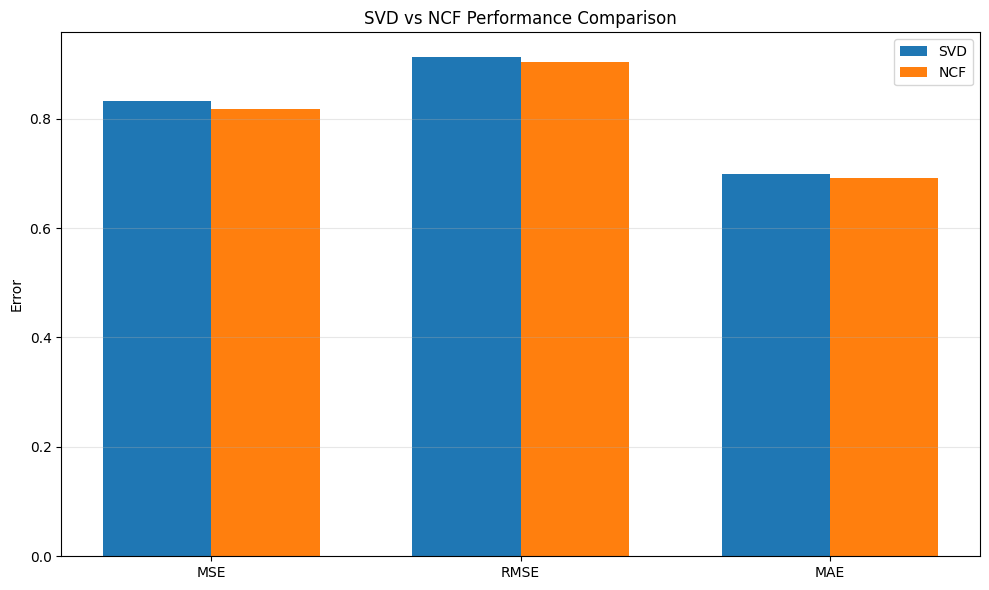

In [ ]:
# ============================================
# STEP 29: FINAL MODEL COMPARISON
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Model comparison
comparison_df = pd.DataFrame({
    "Model": ["SVD", "NCF"],
    "MSE": [svd_mse, ncf_mse],
    "RMSE": [svd_rmse, ncf_rmse],
    "MAE": [svd_mae, ncf_mae]
})

print("========== FINAL MODEL COMPARISON ==========\n")
print(comparison_df.to_string(index=False))

print("\n========== TOP-N RECOMMENDATION METRICS ==========\n")
print(f"Precision@10 : {precision_at_10:.4f}")
print(f"Recall@10    : {recall_at_10:.4f}")
print(f"Hit Rate@10  : {hit_rate_at_10:.4f}")

# Calculate improvement of NCF over SVD
rmse_improvement = ((svd_rmse - ncf_rmse) / svd_rmse) * 100
mae_improvement = ((svd_mae - ncf_mae) / svd_mae) * 100
mse_improvement = ((svd_mse - ncf_mse) / svd_mse) * 100

print("\n========== NCF IMPROVEMENT OVER SVD ==========\n")
print(f"MSE improvement  : {mse_improvement:.2f}%")
print(f"RMSE improvement : {rmse_improvement:.2f}%")
print(f"MAE improvement  : {mae_improvement:.2f}%")

# Visualization
metrics = ["MSE", "RMSE", "MAE"]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    [i - width/2 for i in x],
    comparison_df.iloc[0][metrics],
    width=width,
    label="SVD"
)

plt.bar(
    [i + width/2 for i in x],
    comparison_df.iloc[1][metrics],
    width=width,
    label="NCF"
)

plt.xticks(list(x), metrics)
plt.ylabel("Error")
plt.title("SVD vs NCF Performance Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 30: SAVE TRAINED NCF MODEL
# ============================================

MODEL_PATH = "/content/ncf_movie_recommender.keras"

# Save the trained NCF model
ncf_model.save(MODEL_PATH)

print("========== MODEL SAVED ==========")
print(f"Model saved successfully at:")
print(MODEL_PATH)

# Check model size
import os

model_size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)

print(f"\nModel size: {model_size_mb:.2f} MB")
print("NCF model is ready for future recommendations.")

========== MODEL SAVED ==========
Model saved successfully at:
/content/ncf_movie_recommender.keras

Model size: 298.99 MB
NCF model is ready for future recommendations.


In [ ]:
# ============================================
# STEP 31: SAVE RECOMMENDER DATA
# ============================================

import pickle
import os

# Recreate movie rating counts
movie_rating_counts = (
    ratings_clean.groupby("movieId")
    .size()
    .to_dict()
)

RECOMMENDER_DATA_PATH = "/content/recommender_data.pkl"

recommender_data = {
    "user_to_index": user_to_index,
    "movie_to_index": movie_to_index,
    "index_to_user": {v: k for k, v in user_to_index.items()},
    "index_to_movie": {v: k for k, v in movie_to_index.items()},
    "movie_ids": movie_ids,
    "movie_rating_counts": movie_rating_counts,
    "min_ratings": 20
}

with open(RECOMMENDER_DATA_PATH, "wb") as f:
    pickle.dump(recommender_data, f)

print("========== RECOMMENDER DATA SAVED ==========")
print(f"Saved at: {RECOMMENDER_DATA_PATH}")

file_size_mb = os.path.getsize(RECOMMENDER_DATA_PATH) / (1024 * 1024)
print(f"File size: {file_size_mb:.2f} MB")

print("\nSaved components:")
print("✓ User ID mapping")
print("✓ Movie ID mapping")
print("✓ Reverse mappings")
print("✓ Movie IDs")
print("✓ Movie rating counts")
print("✓ Minimum rating filter")

========== RECOMMENDER DATA SAVED ==========
Saved at: /content/recommender_data.pkl
File size: 12.02 MB

Saved components:
✓ User ID mapping
✓ Movie ID mapping
✓ Reverse mappings
✓ Movie IDs
✓ Movie rating counts
✓ Minimum rating filter


In [ ]:
# ============================================
# STEP 32: TEST SAVED NCF MODEL
# ============================================

import tensorflow as tf

SAVED_MODEL_PATH = "/content/ncf_movie_recommender.keras"

# Load saved model
loaded_ncf_model = tf.keras.models.load_model(SAVED_MODEL_PATH)

print("========== SAVED MODEL TEST ==========")
print("✓ NCF model loaded successfully")
print(f"Total parameters: {loaded_ncf_model.count_params():,}")

# Test prediction using one sample from the test data
sample_user = X_test_users[:1]
sample_movie = X_test_movies[:1]

prediction = loaded_ncf_model.predict(
    [sample_user, sample_movie],
    verbose=0
)

print(f"Test prediction: {float(prediction[0][0]):.4f}")
print(f"Actual rating:   {float(y_test[0]):.4f}")

print("\n✓ Saved model is working correctly!")

========== SAVED MODEL TEST ==========
✓ NCF model loaded successfully
Total parameters: 26,120,801
Test prediction: 1.8102
Actual rating:   1.5000

✓ Saved model is working correctly!


In [ ]:
# ============================================
# STEP 33: FINAL RECOMMENDATION INTERFACE
# ============================================

def final_recommend_movies(user_id, top_n=10):
    """
    Generate personalized movie recommendations for a MovieLens user.
    """

    # Check whether user exists
    if user_id not in user_to_index:
        print(f"User {user_id} is not available in the NCF model.")
        print("Please enter a valid MovieLens user ID.")
        return None

    # Original user index
    user_idx = user_to_index[user_id]

    # Movies already rated by this user
    rated_movies = set(
        ratings_clean.loc[
            ratings_clean["userId"] == user_id,
            "movieId"
        ]
    )

    # Candidate movies:
    # - known to the NCF model
    # - not already rated
    # - at least 20 ratings
    candidates = [
        movie_id
        for movie_id in movie_ids
        if movie_id not in rated_movies
        and movie_rating_counts.get(movie_id, 0) >= 20
    ]

    if len(candidates) == 0:
        print("No suitable recommendation candidates found.")
        return None

    # Convert candidate movie IDs to model indices
    candidate_indices = np.array(
        [movie_to_index[movie_id] for movie_id in candidates],
        dtype=np.int32
    )

    # User input repeated for every candidate
    user_indices = np.full(
        len(candidate_indices),
        user_idx,
        dtype=np.int32
    )

    # Predict in batches
    predictions = loaded_ncf_model.predict(
        [user_indices, candidate_indices],
        batch_size=4096,
        verbose=0
    ).flatten()

    # Create recommendation dataframe
    recommendations = pd.DataFrame({
        "movieId": candidates,
        "predicted_rating": predictions
    })

    # Sort by predicted rating
    recommendations = recommendations.sort_values(
        "predicted_rating",
        ascending=False
    ).head(top_n)

    # Add movie information
    recommendations = recommendations.merge(
        movies[["movieId", "title", "genres"]],
        on="movieId",
        how="left"
    )

    # Add rating count
    recommendations["rating_count"] = (
        recommendations["movieId"]
        .map(movie_rating_counts)
    )

    # Arrange columns
    recommendations = recommendations[
        [
            "movieId",
            "title",
            "genres",
            "predicted_rating",
            "rating_count"
        ]
    ].reset_index(drop=True)

    # Display
    print("\n" + "=" * 65)
    print(f"PERSONALIZED MOVIE RECOMMENDATIONS")
    print("=" * 65)
    print(f"User ID              : {user_id}")
    print(f"Number of movies rated: {len(rated_movies):,}")
    print(f"Recommendations       : Top {top_n}")
    print("=" * 65)

    display(
        recommendations.style
        .format({
            "predicted_rating": "{:.2f}",
            "rating_count": "{:,}"
        })
    )

    return recommendations


# ============================================
# DEMO
# ============================================

recommendations_demo = final_recommend_movies(
    user_id=1,
    top_n=10
)


PERSONALIZED MOVIE RECOMMENDATIONS
User ID              : 1
Number of movies rated: 62
Recommendations       : Top 10


,movieId,title,genres,predicted_rating,rating_count
0,159817,Planet Earth (2006),Documentary,4.62,"3,015"
1,26003,Night and Fog (Nuit et brouillard) (1955),Crime|Documentary|War,4.57,604
2,171011,Planet Earth II (2016),Documentary,4.55,"2,041"
3,198185,Twin Peaks (1989),Drama|Mystery,4.52,"1,132"
4,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.49,"122,296"
5,326,To Live (Huozhe) (1994),Drama,4.49,"1,572"
6,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,4.48,"9,627"
7,858,"Godfather, The (1972)",Crime|Drama,4.44,"75,004"
8,8199,Ugetsu (Ugetsu monogatari) (1953),Drama|Thriller,4.43,674
9,136469,Larry David: Curb Your Enthusiasm (1999),Comedy,4.42,475


In [ ]:
# ============================================
# STEP 34: FINAL MULTI-USER TEST
# ============================================

test_users = [1, 249306, 229976, 189614]

print("=" * 75)
print("FINAL MULTI-USER RECOMMENDATION TEST")
print("=" * 75)

for user_id in test_users:

    print(f"\n>>> Testing User ID: {user_id}")

    result = final_recommend_movies(
        user_id=user_id,
        top_n=5
    )

    if result is not None:

        # Check for duplicate recommendations
        duplicate_count = result["movieId"].duplicated().sum()

        # Check whether recommended movies were already rated
        rated_movies = set(
            ratings_clean.loc[
                ratings_clean["userId"] == user_id,
                "movieId"
            ]
        )

        already_rated_count = sum(
            movie_id in rated_movies
            for movie_id in result["movieId"]
        )

        # Check minimum rating count
        min_rating_count = result["rating_count"].min()

        print("\nValidation:")
        print(f"  Recommendations generated : {len(result)}")
        print(f"  Duplicate movies          : {duplicate_count}")
        print(f"  Already-rated movies      : {already_rated_count}")
        print(f"  Minimum rating count      : {min_rating_count}")

        if (
            duplicate_count == 0
            and already_rated_count == 0
            and min_rating_count >= 20
        ):
            print("  ✓ PASSED")
        else:
            print("  ✗ FAILED")

print("\n" + "=" * 75)
print("FINAL MULTI-USER TEST COMPLETED")
print("=" * 75)

FINAL MULTI-USER RECOMMENDATION TEST

>>> Testing User ID: 1

PERSONALIZED MOVIE RECOMMENDATIONS
User ID              : 1
Number of movies rated: 62
Recommendations       : Top 5


,movieId,title,genres,predicted_rating,rating_count
0,159817,Planet Earth (2006),Documentary,4.62,"3,015"
1,26003,Night and Fog (Nuit et brouillard) (1955),Crime|Documentary|War,4.57,604
2,171011,Planet Earth II (2016),Documentary,4.55,"2,041"
3,198185,Twin Peaks (1989),Drama|Mystery,4.52,"1,132"
4,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.49,"122,296"



Validation:
  Recommendations generated : 5
  Duplicate movies          : 0
  Already-rated movies      : 0
  Minimum rating count      : 604
  ✓ PASSED

>>> Testing User ID: 249306

PERSONALIZED MOVIE RECOMMENDATIONS
User ID              : 249306
Number of movies rated: 31
Recommendations       : Top 5


,movieId,title,genres,predicted_rating,rating_count
0,159817,Planet Earth (2006),Documentary,4.56,"3,015"
1,26003,Night and Fog (Nuit et brouillard) (1955),Crime|Documentary|War,4.50,604
2,171011,Planet Earth II (2016),Documentary,4.47,"2,041"
3,198185,Twin Peaks (1989),Drama|Mystery,4.46,"1,132"
4,326,To Live (Huozhe) (1994),Drama,4.43,"1,572"



Validation:
  Recommendations generated : 5
  Duplicate movies          : 0
  Already-rated movies      : 0
  Minimum rating count      : 604
  ✓ PASSED

>>> Testing User ID: 229976

PERSONALIZED MOVIE RECOMMENDATIONS
User ID              : 229976
Number of movies rated: 98
Recommendations       : Top 5


,movieId,title,genres,predicted_rating,rating_count
0,159817,Planet Earth (2006),Documentary,4.27,"3,015"
1,26003,Night and Fog (Nuit et brouillard) (1955),Crime|Documentary|War,4.20,604
2,171011,Planet Earth II (2016),Documentary,4.20,"2,041"
3,198185,Twin Peaks (1989),Drama|Mystery,4.18,"1,132"
4,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,4.13,"9,627"



Validation:
  Recommendations generated : 5
  Duplicate movies          : 0
  Already-rated movies      : 0
  Minimum rating count      : 604
  ✓ PASSED

>>> Testing User ID: 189614

PERSONALIZED MOVIE RECOMMENDATIONS
User ID              : 189614
Number of movies rated: 33,332
Recommendations       : Top 5


,movieId,title,genres,predicted_rating,rating_count
0,198185,Twin Peaks (1989),Drama|Mystery,4.17,"1,132"
1,136469,Larry David: Curb Your Enthusiasm (1999),Comedy,4.15,475
2,720,Wallace & Gromit: The Best of Aardman Animation (1996),Adventure|Animation|Comedy,4.08,"9,950"
3,179135,Blue Planet II (2017),Documentary,4.01,"1,267"
4,228099,Firefly (2002),Action|Adventure|Sci-Fi|Western,4.01,895



Validation:
  Recommendations generated : 5
  Duplicate movies          : 0
  Already-rated movies      : 0
  Minimum rating count      : 475
  ✓ PASSED

FINAL MULTI-USER TEST COMPLETED


In [ ]:
# ============================================
# STEP 35: FINAL PROJECT RESULTS SUMMARY
# ============================================

final_results = pd.DataFrame({
    "Category": [
        "Dataset",
        "Total Ratings",
        "Total Users",
        "Total Movies",
        "Training Ratings",
        "Testing Ratings",
        "NCF Training Samples",
        "NCF Evaluation Samples",
        "SVD RMSE",
        "NCF RMSE",
        "SVD MAE",
        "NCF MAE",
        "SVD MSE",
        "NCF MSE",
        "Precision@10",
        "Recall@10",
        "Hit Rate@10"
    ],
    "Result": [
        "MovieLens Latest",
        f"{len(ratings_clean):,}",
        f"{ratings_clean['userId'].nunique():,}",
        f"{movies['movieId'].nunique():,}",
        f"{len(train_df):,}",
        f"{len(test_df):,}",
        f"{len(train_sample):,}",
        f"{len(test_sample):,}",
        f"{svd_rmse:.4f}",
        f"{ncf_rmse:.4f}",
        f"{svd_mae:.4f}",
        f"{ncf_mae:.4f}",
        f"{svd_mse:.4f}",
        f"{ncf_mse:.4f}",
        f"{precision_at_10:.4f}",
        f"{recall_at_10:.4f}",
        f"{hit_rate_at_10:.4f}"
    ]
})

print("=" * 70)
print("FINAL PROJECT RESULTS SUMMARY")
print("=" * 70)

display(final_results)

print("\n========== BEST MODEL ==========")
print("NCF (Neural Collaborative Filtering)")

print("\n========== CONCLUSION ==========")
print(
    "NCF achieved lower MSE, RMSE, and MAE than the SVD baseline, "
    "making NCF the better-performing rating prediction model in this experiment."
)

FINAL PROJECT RESULTS SUMMARY


,Category,Result
0,Dataset,MovieLens Latest
1,Total Ratings,"33,832,162"
2,Total Users,"330,975"
3,Total Movies,"86,537"
4,Training Ratings,"27,065,729"
5,Testing Ratings,"6,766,433"
6,NCF Training Samples,"2,000,000"
7,NCF Evaluation Samples,"500,000"
8,SVD RMSE,0.9123
9,NCF RMSE,0.9043



========== BEST MODEL ==========
NCF (Neural Collaborative Filtering)

========== CONCLUSION ==========
NCF achieved lower MSE, RMSE, and MAE than the SVD baseline, making NCF the better-performing rating prediction model in this experiment.


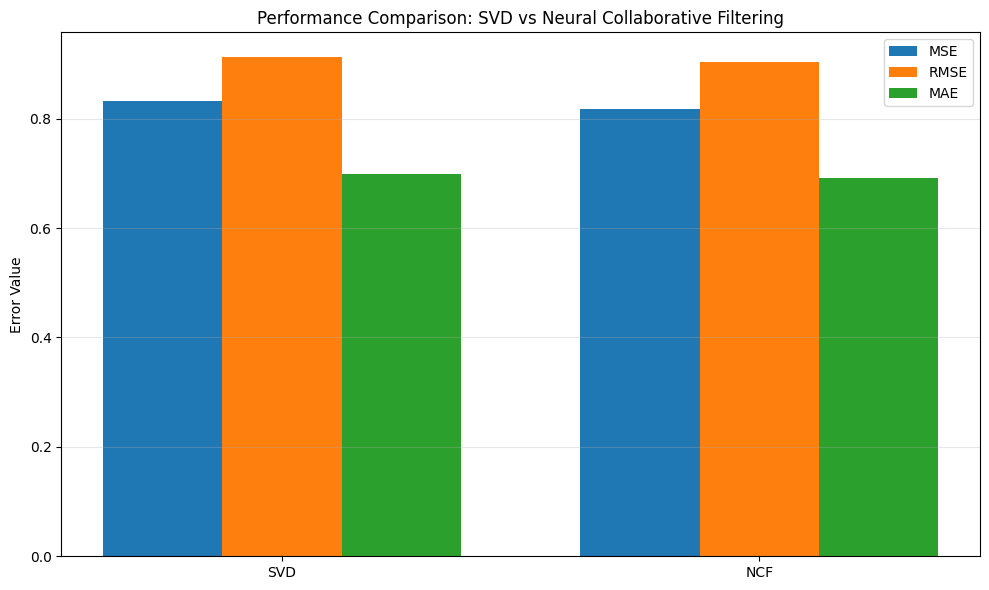

========== FINAL PERFORMANCE CHART ==========
✓ SVD and NCF comparison visualized
✓ MSE, RMSE, and MAE included


In [ ]:
# ============================================
# STEP 36: FINAL PERFORMANCE VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import numpy as np

models = ["SVD", "NCF"]

mse_values = [svd_mse, ncf_mse]
rmse_values = [svd_rmse, ncf_rmse]
mae_values = [svd_mae, ncf_mae]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, mse_values, width, label="MSE")
plt.bar(x, rmse_values, width, label="RMSE")
plt.bar(x + width, mae_values, width, label="MAE")

plt.xticks(x, models)
plt.ylabel("Error Value")
plt.title("Performance Comparison: SVD vs Neural Collaborative Filtering")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("========== FINAL PERFORMANCE CHART ==========")
print("✓ SVD and NCF comparison visualized")
print("✓ MSE, RMSE, and MAE included")

In [ ]:
# ============================================
# STEP 37: PREPARE UI FILES
# ============================================

import os
import shutil

UI_DIR = "/content/movie_recommender_app"

# Create application folder
os.makedirs(UI_DIR, exist_ok=True)

# Copy trained model
shutil.copy(
    "/content/ncf_movie_recommender.keras",
    f"{UI_DIR}/ncf_movie_recommender.keras"
)

# Copy recommender mappings/data
shutil.copy(
    "/content/recommender_data.pkl",
    f"{UI_DIR}/recommender_data.pkl"
)

# Copy movie information
shutil.copy(
    "/content/movielens/ml-latest/movies.csv",
    f"{UI_DIR}/movies.csv"
)

print("=" * 60)
print("UI FILES PREPARED")
print("=" * 60)

for filename in os.listdir(UI_DIR):
    filepath = os.path.join(UI_DIR, filename)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    print(f"✓ {filename:<35} {size_mb:.2f} MB")

print("\nApplication folder:")
print(UI_DIR)

UI FILES PREPARED
✓ ncf_movie_recommender.keras         298.99 MB
✓ movies.csv                          4.00 MB
✓ recommender_data.pkl                12.02 MB

Application folder:
/content/movie_recommender_app


Generating train predictions...
Generating validation predictions...
Generating test predictions...

CLASSIFICATION-STYLE EVALUATION

Relevance threshold : 4.0

---------- ACCURACY ----------
Train Accuracy      : 0.6881 (68.81%)
Validation Accuracy : 0.6868 (68.68%)
Test Accuracy       : 0.6352 (63.52%)

---------- CONFUSION MATRIX ----------
Rows    = Actual
Columns = Predicted

              Predicted
              0       1
Actual 0    226644   23672
Actual 1    158711   90973

---------- CLASSIFICATION REPORT ----------
                   precision    recall  f1-score   support

Not Relevant (<4)       0.59      0.91      0.71    250316
   Relevant (>=4)       0.79      0.36      0.50    249684

         accuracy                           0.64    500000
        macro avg       0.69      0.63      0.61    500000
     weighted avg       0.69      0.64      0.61    500000



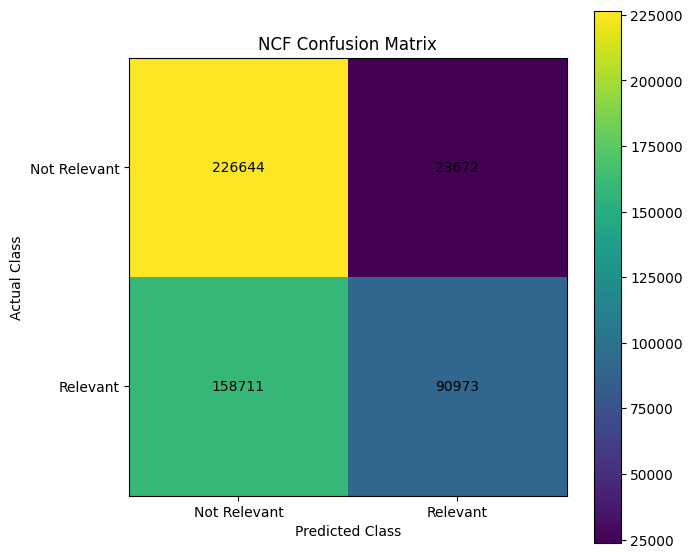


✓ Classification-style evaluation completed!


In [ ]:
# ============================================
# CLASSIFICATION-STYLE EVALUATION
# Confusion Matrix + Train/Val/Test Accuracy
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report
)

THRESHOLD = 4.0

# ------------------------------------------------
# Create Train / Validation split from NCF sample
# ------------------------------------------------

rng = np.random.RandomState(42)

indices = np.arange(len(X_train_users))
rng.shuffle(indices)

split_point = int(0.80 * len(indices))

train_idx = indices[:split_point]
val_idx = indices[split_point:]

X_train_users_eval = X_train_users[train_idx]
X_train_movies_eval = X_train_movies[train_idx]
y_train_eval = y_train[train_idx]

X_val_users_eval = X_train_users[val_idx]
X_val_movies_eval = X_train_movies[val_idx]
y_val_eval = y_train[val_idx]

# ------------------------------------------------
# Predictions
# ------------------------------------------------

print("Generating train predictions...")

train_pred = loaded_ncf_model.predict(
    [X_train_users_eval, X_train_movies_eval],
    batch_size=4096,
    verbose=0
).flatten()

print("Generating validation predictions...")

val_pred = loaded_ncf_model.predict(
    [X_val_users_eval, X_val_movies_eval],
    batch_size=4096,
    verbose=0
).flatten()

print("Generating test predictions...")

test_pred = loaded_ncf_model.predict(
    [X_test_users, X_test_movies],
    batch_size=4096,
    verbose=0
).flatten()

# ------------------------------------------------
# Convert ratings into binary classes
# ------------------------------------------------

y_train_class = (y_train_eval >= THRESHOLD).astype(int)
train_pred_class = (train_pred >= THRESHOLD).astype(int)

y_val_class = (y_val_eval >= THRESHOLD).astype(int)
val_pred_class = (val_pred >= THRESHOLD).astype(int)

y_test_class = (y_test >= THRESHOLD).astype(int)
test_pred_class = (test_pred >= THRESHOLD).astype(int)

# ------------------------------------------------
# Accuracy
# ------------------------------------------------

train_accuracy = accuracy_score(
    y_train_class,
    train_pred_class
)

val_accuracy = accuracy_score(
    y_val_class,
    val_pred_class
)

test_accuracy = accuracy_score(
    y_test_class,
    test_pred_class
)

# ------------------------------------------------
# Confusion Matrix on Test Set
# ------------------------------------------------

cm = confusion_matrix(
    y_test_class,
    test_pred_class
)

# ------------------------------------------------
# Results
# ------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION-STYLE EVALUATION")
print("=" * 60)

print(f"\nRelevance threshold : {THRESHOLD}")

print("\n---------- ACCURACY ----------")
print(f"Train Accuracy      : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Validation Accuracy : {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Test Accuracy       : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\n---------- CONFUSION MATRIX ----------")
print("Rows    = Actual")
print("Columns = Predicted")
print("\n              Predicted")
print("              0       1")
print(f"Actual 0   {cm[0,0]:7d} {cm[0,1]:7d}")
print(f"Actual 1   {cm[1,0]:7d} {cm[1,1]:7d}")

print("\n---------- CLASSIFICATION REPORT ----------")

print(
    classification_report(
        y_test_class,
        test_pred_class,
        target_names=[
            "Not Relevant (<4)",
            "Relevant (>=4)"
        ]
    )
)

# ------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("NCF Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Not Relevant", "Relevant"]
)

plt.yticks(
    [0, 1],
    ["Not Relevant", "Relevant"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

print("\n✓ Classification-style evaluation completed!")

In [ ]:
# ============================================
# STEP 37: FIND BEST CLASSIFICATION THRESHOLD
# ============================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

thresholds = np.arange(2.5, 5.01, 0.1)

results = []

for threshold in thresholds:

    actual = (y_val_eval >= threshold).astype(int)
    predicted = (val_pred >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted, zero_division=0),
        "Recall": recall_score(actual, predicted, zero_division=0),
        "F1": f1_score(actual, predicted, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

# Best threshold according to validation accuracy
best_accuracy_row = threshold_results.loc[
    threshold_results["Accuracy"].idxmax()
]

# Best threshold according to F1
best_f1_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print("=" * 65)
print("THRESHOLD ANALYSIS")
print("=" * 65)

print("\nBest threshold based on Validation Accuracy:")
print(f"Threshold : {best_accuracy_row['Threshold']:.1f}")
print(f"Accuracy  : {best_accuracy_row['Accuracy']:.4f}")
print(f"Precision : {best_accuracy_row['Precision']:.4f}")
print(f"Recall    : {best_accuracy_row['Recall']:.4f}")
print(f"F1 Score  : {best_accuracy_row['F1']:.4f}")

print("\nBest threshold based on Validation F1:")
print(f"Threshold : {best_f1_row['Threshold']:.1f}")
print(f"Accuracy  : {best_f1_row['Accuracy']:.4f}")
print(f"Precision : {best_f1_row['Precision']:.4f}")
print(f"Recall    : {best_f1_row['Recall']:.4f}")
print(f"F1 Score  : {best_f1_row['F1']:.4f}")

print("\nTop 10 thresholds by validation accuracy:")
display(
    threshold_results
    .sort_values("Accuracy", ascending=False)
    .head(10)
    .style.format({
        "Threshold": "{:.1f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

THRESHOLD ANALYSIS

Best threshold based on Validation Accuracy:
Threshold : 5.0
Accuracy  : 0.9978
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000

Best threshold based on Validation F1:
Threshold : 2.5
Accuracy  : 0.8948
Precision : 0.9102
Recall    : 0.9759
F1 Score  : 0.9419

Top 10 thresholds by validation accuracy:


,Threshold,Accuracy,Precision,Recall,F1
25,5.0,0.9978,0.0000,0.0000,0.0000
0,2.5,0.8948,0.9102,0.9759,0.9419
20,4.5,0.8702,0.6848,0.2226,0.3360
21,4.6,0.8677,0.7503,0.1546,0.2563
22,4.7,0.8633,0.8047,0.0973,0.1736
2,2.7,0.8616,0.8786,0.9648,0.9197
1,2.6,0.8603,0.8700,0.9759,0.9199
3,2.8,0.8601,0.8879,0.9496,0.9177
23,4.8,0.8593,0.8581,0.0558,0.1047
24,4.9,0.8563,0.8936,0.0293,0.0568


In [ ]:
# ============================================
# STEP 37: PREPARE CLASSIFICATION DATA
# ============================================

import numpy as np
import pandas as pd

CLASSIFICATION_THRESHOLD = 4.0

print("=" * 65)
print("PREPARING NCF CLASSIFICATION DATA")
print("=" * 65)

# Use the same 2M NCF training sample
# Convert ratings into binary labels
y_classification = (
    y_train >= CLASSIFICATION_THRESHOLD
).astype(np.float32)

# Test labels
y_test_classification = (
    y_test >= CLASSIFICATION_THRESHOLD
).astype(np.float32)

# Display class distribution
train_not_relevant = np.sum(y_classification == 0)
train_relevant = np.sum(y_classification == 1)

test_not_relevant = np.sum(y_test_classification == 0)
test_relevant = np.sum(y_test_classification == 1)

print("\nClassification rule:")
print(f"Rating < {CLASSIFICATION_THRESHOLD}  → Not Relevant (0)")
print(f"Rating >= {CLASSIFICATION_THRESHOLD} → Relevant (1)")

print("\n========== TRAINING DATA ==========")
print(f"Total samples       : {len(y_classification):,}")
print(f"Not Relevant (0)    : {train_not_relevant:,}")
print(f"Relevant (1)        : {train_relevant:,}")
print(f"Not Relevant %      : {train_not_relevant / len(y_classification) * 100:.2f}%")
print(f"Relevant %          : {train_relevant / len(y_classification) * 100:.2f}%")

print("\n========== TEST DATA ==========")
print(f"Total samples       : {len(y_test_classification):,}")
print(f"Not Relevant (0)    : {test_not_relevant:,}")
print(f"Relevant (1)        : {test_relevant:,}")
print(f"Not Relevant %      : {test_not_relevant / len(y_test_classification) * 100:.2f}%")
print(f"Relevant %          : {test_relevant / len(y_test_classification) * 100:.2f}%")

print("\n✓ Classification labels prepared successfully!")

PREPARING NCF CLASSIFICATION DATA

Classification rule:
Rating < 4.0  → Not Relevant (0)
Rating >= 4.0 → Relevant (1)

========== TRAINING DATA ==========
Total samples       : 2,000,000
Not Relevant (0)    : 1,000,284
Relevant (1)        : 999,716
Not Relevant %      : 50.01%
Relevant %          : 49.99%

========== TEST DATA ==========
Total samples       : 500,000
Not Relevant (0)    : 250,316
Relevant (1)        : 249,684
Not Relevant %      : 50.06%
Relevant %          : 49.94%

✓ Classification labels prepared successfully!


In [ ]:
# ============================================
# STEP 38: BUILD NCF CLASSIFICATION MODEL
# ============================================

import tensorflow as tf
from tensorflow.keras import layers, Model

print("=" * 65)
print("BUILDING NCF CLASSIFICATION MODEL")
print("=" * 65)

# Reproducibility
tf.random.set_seed(42)

# Number of users and movies
num_users = len(user_to_index)
num_movies = len(movie_to_index)

# Embedding dimensions
embedding_dim = 32

# --------------------------------------------
# Inputs
# --------------------------------------------

user_input = layers.Input(
    shape=(1,),
    name="user_input"
)

movie_input = layers.Input(
    shape=(1,),
    name="movie_input"
)

# --------------------------------------------
# GMF Branch
# --------------------------------------------

gmf_user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=embedding_dim,
    name="gmf_user_embedding"
)(user_input)

gmf_movie_embedding = layers.Embedding(
    input_dim=num_movies,
    output_dim=embedding_dim,
    name="gmf_movie_embedding"
)(movie_input)

gmf_user_embedding = layers.Flatten()(gmf_user_embedding)
gmf_movie_embedding = layers.Flatten()(gmf_movie_embedding)

gmf_output = layers.Multiply()([
    gmf_user_embedding,
    gmf_movie_embedding
])

# --------------------------------------------
# MLP Branch
# --------------------------------------------

mlp_user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=embedding_dim,
    name="mlp_user_embedding"
)(user_input)

mlp_movie_embedding = layers.Embedding(
    input_dim=num_movies,
    output_dim=embedding_dim,
    name="mlp_movie_embedding"
)(movie_input)

mlp_user_embedding = layers.Flatten()(mlp_user_embedding)
mlp_movie_embedding = layers.Flatten()(mlp_movie_embedding)

mlp_output = layers.Concatenate()([
    mlp_user_embedding,
    mlp_movie_embedding
])

mlp_output = layers.Dense(
    64,
    activation="relu"
)(mlp_output)

mlp_output = layers.Dropout(0.2)(mlp_output)

mlp_output = layers.Dense(
    32,
    activation="relu"
)(mlp_output)

# --------------------------------------------
# Combine GMF + MLP
# --------------------------------------------

combined = layers.Concatenate()([
    gmf_output,
    mlp_output
])

combined = layers.Dense(
    32,
    activation="relu"
)(combined)

combined = layers.Dropout(0.2)(combined)

# --------------------------------------------
# Classification Output
# --------------------------------------------

output = layers.Dense(
    1,
    activation="sigmoid",
    name="relevance_probability"
)(combined)

# --------------------------------------------
# Create Model
# --------------------------------------------

ncf_classifier = Model(
    inputs=[user_input, movie_input],
    outputs=output,
    name="NCF_Classifier"
)

# --------------------------------------------
# Compile
# --------------------------------------------

ncf_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# --------------------------------------------
# Display Model
# --------------------------------------------

ncf_classifier.summary()

print("\n✓ NCF classification model created successfully!")
print("✓ Output: Probability of movie being relevant")
print("✓ Loss: Binary Cross-Entropy")
print("✓ Metrics: Accuracy, Precision, Recall")

BUILDING NCF CLASSIFICATION MODEL


Model: "NCF_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_user_embedding  │ (None, 1, 32)     │ 10,524,608 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_movie_embedding │ (None, 1, 32)     │  2,532,640 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 32)        │          0 │ mlp_user_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 32)        │          0 │ mlp_movie_embedd… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64)        │          0 │ flatten_6[0][0],  │
│ (Concatenate)       │                   │            │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmf_user_embedding  │ (None, 1, 32)     │ 10,524,608 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmf_movie_embedding │ (None, 1, 32)     │  2,532,640 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 32)        │          0 │ gmf_user_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 32)        │          0 │ gmf_movie_embedd… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 32)        │          0 │ flatten_4[0][0],  │
│ (Multiply)          │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64)        │          0 │ multiply_1[0][0], │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relevance_probabil… │ (None, 1)         │         33 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,122,849 (99.65 MB)

 Trainable params: 26,122,849 (99.65 MB)

 Non-trainable params: 0 (0.00 B)


✓ NCF classification model created successfully!
✓ Output: Probability of movie being relevant
✓ Loss: Binary Cross-Entropy
✓ Metrics: Accuracy, Precision, Recall


In [ ]:
# ============================================
# STEP 39: TRAIN NCF CLASSIFICATION MODEL
# ============================================

import tensorflow as tf

print("=" * 65)
print("TRAINING NCF CLASSIFICATION MODEL")
print("=" * 65)

# ------------------------------------------------
# Create TensorFlow dataset
# ------------------------------------------------

classification_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            "user_input": X_train_users,
            "movie_input": X_train_movies
        },
        y_classification
    )
)

# Shuffle before splitting
classification_dataset = classification_dataset.shuffle(
    buffer_size=100000,
    seed=42,
    reshuffle_each_iteration=False
)

# 80% training / 20% validation
classification_train_size = int(
    0.80 * len(y_classification)
)

classification_train_ds = classification_dataset.take(
    classification_train_size
)

classification_val_ds = classification_dataset.skip(
    classification_train_size
)

# Batch
BATCH_SIZE_CLASS = 4096

classification_train_ds = (
    classification_train_ds
    .batch(BATCH_SIZE_CLASS)
    .prefetch(tf.data.AUTOTUNE)
)

classification_val_ds = (
    classification_val_ds
    .batch(BATCH_SIZE_CLASS)
    .prefetch(tf.data.AUTOTUNE)
)

# ------------------------------------------------
# Early stopping
# ------------------------------------------------

early_stopping_classifier = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------
# Train
# ------------------------------------------------

history_classifier = ncf_classifier.fit(
    classification_train_ds,
    validation_data=classification_val_ds,
    epochs=8,
    callbacks=[early_stopping_classifier],
    verbose=1
)

print("\n" + "=" * 65)
print("CLASSIFICATION NCF TRAINING COMPLETED")
print("=" * 65)

print(f"Best validation accuracy: "
      f"{max(history_classifier.history['val_accuracy']):.4f}")

print(f"Best validation loss: "
      f"{min(history_classifier.history['val_loss']):.4f}")

print("\n✓ Training completed successfully!")

TRAINING NCF CLASSIFICATION MODEL
Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 149s 363ms/step - accuracy: 0.6672 - loss: 0.6062 - precision: 0.6553 - recall: 0.7048 - val_accuracy: 0.7001 - val_loss: 0.5730 - val_precision: 0.6872 - val_recall: 0.7346
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 202s 368ms/step - accuracy: 0.7427 - loss: 0.5188 - precision: 0.7357 - recall: 0.7572 - val_accuracy: 0.6965 - val_loss: 0.5839 - val_precision: 0.6837 - val_recall: 0.7318
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 362ms/step - accuracy: 0.8545 - loss: 0.3391 - precision: 0.8564 - recall: 0.8517 - val_accuracy: 0.6566 - val_loss: 0.7692 - val_precision: 0.6546 - val_recall: 0.6632
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

CLASSIFICATION NCF TRAINING COMPLETED
Best validation accuracy: 0.7001
Best validation loss: 0.5730

✓ Training completed successfully!


NCF CLASSIFICATION MODEL EVALUATION

Generating train predictions...
Generating validation predictions...
Generating test predictions...

========== ACCURACY ==========
Train Accuracy      : 0.7414 (74.14%)
Validation Accuracy : 0.7414 (74.14%)
Test Accuracy       : 0.6987 (69.87%)

========== TEST METRICS ==========
Precision : 0.6855
Recall    : 0.7330
F1 Score : 0.7085

========== CONFUSION MATRIX ==========
Rows    = Actual
Columns = Predicted

                 Predicted
                 0       1
Actual 0       166347   83969
Actual 1        66666  183018

========== CLASSIFICATION REPORT ==========
                   precision    recall  f1-score   support

Not Relevant (<4)       0.71      0.66      0.69    250316
   Relevant (>=4)       0.69      0.73      0.71    249684

         accuracy                           0.70    500000
        macro avg       0.70      0.70      0.70    500000
     weighted avg       0.70      0.70      0.70    500000



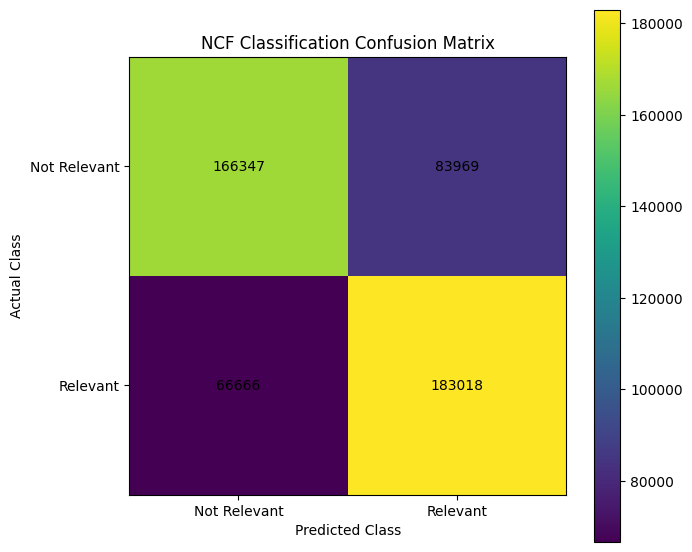


✓ NCF classification evaluation completed successfully!


In [ ]:
# ============================================
# STEP 40: EVALUATE NCF CLASSIFICATION MODEL
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 65)
print("NCF CLASSIFICATION MODEL EVALUATION")
print("=" * 65)

# ------------------------------------------------
# Generate predictions
# ------------------------------------------------

print("\nGenerating train predictions...")

train_prob = ncf_classifier.predict(
    [X_train_users_eval, X_train_movies_eval],
    batch_size=4096,
    verbose=0
).flatten()

print("Generating validation predictions...")

val_prob = ncf_classifier.predict(
    [X_val_users_eval, X_val_movies_eval],
    batch_size=4096,
    verbose=0
).flatten()

print("Generating test predictions...")

test_prob = ncf_classifier.predict(
    [X_test_users, X_test_movies],
    batch_size=4096,
    verbose=0
).flatten()

# ------------------------------------------------
# Convert probabilities to classes
# ------------------------------------------------

train_pred_class = (train_prob >= 0.5).astype(int)
val_pred_class = (val_prob >= 0.5).astype(int)
test_pred_class = (test_prob >= 0.5).astype(int)

# ------------------------------------------------
# Accuracy
# ------------------------------------------------

train_accuracy = accuracy_score(
    y_train_class,
    train_pred_class
)

val_accuracy = accuracy_score(
    y_val_class,
    val_pred_class
)

test_accuracy = accuracy_score(
    y_test_classification,
    test_pred_class
)

# ------------------------------------------------
# Precision / Recall / F1
# ------------------------------------------------

test_precision = precision_score(
    y_test_classification,
    test_pred_class
)

test_recall = recall_score(
    y_test_classification,
    test_pred_class
)

test_f1 = f1_score(
    y_test_classification,
    test_pred_class
)

# ------------------------------------------------
# Confusion Matrix
# ------------------------------------------------

cm_classifier = confusion_matrix(
    y_test_classification,
    test_pred_class
)

# ------------------------------------------------
# Print Results
# ------------------------------------------------

print("\n========== ACCURACY ==========")

print(
    f"Train Accuracy      : "
    f"{train_accuracy:.4f} ({train_accuracy * 100:.2f}%)"
)

print(
    f"Validation Accuracy : "
    f"{val_accuracy:.4f} ({val_accuracy * 100:.2f}%)"
)

print(
    f"Test Accuracy       : "
    f"{test_accuracy:.4f} ({test_accuracy * 100:.2f}%)"
)

print("\n========== TEST METRICS ==========")

print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

print("\n========== CONFUSION MATRIX ==========")

print("Rows    = Actual")
print("Columns = Predicted")
print()
print("                 Predicted")
print("                 0       1")
print(
    f"Actual 0      {cm_classifier[0,0]:7d} "
    f"{cm_classifier[0,1]:7d}"
)
print(
    f"Actual 1      {cm_classifier[1,0]:7d} "
    f"{cm_classifier[1,1]:7d}"
)

# ------------------------------------------------
# Classification Report
# ------------------------------------------------

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test_classification,
        test_pred_class,
        target_names=[
            "Not Relevant (<4)",
            "Relevant (>=4)"
        ]
    )
)

# ------------------------------------------------
# Confusion Matrix Plot
# ------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(cm_classifier)

plt.title("NCF Classification Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Not Relevant", "Relevant"]
)

plt.yticks(
    [0, 1],
    ["Not Relevant", "Relevant"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_classifier[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

print("\n✓ NCF classification evaluation completed successfully!")

In [ ]:
# ============================================
# DOWNLOAD ALL PROJECT FILES AS ONE ZIP
# ============================================

import os
import shutil
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = "/content/Movie_Recommendation_Project"
os.makedirs(PROJECT_DIR, exist_ok=True)

# --------------------------------------------
# 1. Copy trained models and recommender data
# --------------------------------------------

files_to_copy = [
    "/content/ncf_movie_recommender.keras",
    "/content/recommender_data.pkl"
]

# Classification model, if Step 39 has already created it
if "ncf_classifier" in globals():
    CLASSIFIER_PATH = "/content/ncf_movie_classifier.keras"
    ncf_classifier.save(CLASSIFIER_PATH)
    files_to_copy.append(CLASSIFIER_PATH)

for file_path in files_to_copy:
    if os.path.exists(file_path):
        shutil.copy(file_path, PROJECT_DIR)

# --------------------------------------------
# 2. Save Model Comparison Graph
# --------------------------------------------

models = ["SVD", "NCF"]

mse_values = [svd_mse, ncf_mse]
rmse_values = [svd_rmse, ncf_rmse]
mae_values = [svd_mae, ncf_mae]

x = range(len(models))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    [i - width for i in x],
    mse_values,
    width,
    label="MSE"
)

plt.bar(
    x,
    rmse_values,
    width,
    label="RMSE"
)

plt.bar(
    [i + width for i in x],
    mae_values,
    width,
    label="MAE"
)

plt.xticks(list(x), models)
plt.ylabel("Error Value")
plt.title("Performance Comparison: SVD vs Neural Collaborative Filtering")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/01_SVD_vs_NCF_Performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# --------------------------------------------
# 3. Save Training Loss Graph
# --------------------------------------------

if "history" in globals():

    plt.figure(figsize=(10, 6))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("NCF Training and Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        f"{PROJECT_DIR}/02_NCF_Training_Validation_Loss.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# --------------------------------------------
# 4. Save Training MAE Graph
# --------------------------------------------

if "history" in globals():

    plt.figure(figsize=(10, 6))

    plt.plot(
        history.history["mae"],
        label="Training MAE"
    )

    plt.plot(
        history.history["val_mae"],
        label="Validation MAE"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title("NCF Training and Validation MAE")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        f"{PROJECT_DIR}/03_NCF_Training_Validation_MAE.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# --------------------------------------------
# 5. Save Classification Confusion Matrix
# --------------------------------------------

if "cm_classifier" in globals():

    plt.figure(figsize=(7, 6))

    plt.imshow(cm_classifier)

    plt.title("NCF Classification Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.xticks(
        [0, 1],
        ["Not Relevant", "Relevant"]
    )

    plt.yticks(
        [0, 1],
        ["Not Relevant", "Relevant"]
    )

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm_classifier[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()

    plt.tight_layout()

    plt.savefig(
        f"{PROJECT_DIR}/04_Confusion_Matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# --------------------------------------------
# 6. Save Final Results CSV
# --------------------------------------------

final_results = pd.DataFrame({
    "Model": ["SVD", "NCF"],
    "MSE": [svd_mse, ncf_mse],
    "RMSE": [svd_rmse, ncf_rmse],
    "MAE": [svd_mae, ncf_mae]
})

final_results.to_csv(
    f"{PROJECT_DIR}/05_Model_Results.csv",
    index=False
)

# --------------------------------------------
# 7. Save Top-N Results
# --------------------------------------------

top_n_results = pd.DataFrame({
    "Metric": [
        "Precision@10",
        "Recall@10",
        "Hit Rate@10"
    ],
    "Value": [
        precision_at_10,
        recall_at_10,
        hit_rate_at_10
    ]
})

top_n_results.to_csv(
    f"{PROJECT_DIR}/06_Top_N_Results.csv",
    index=False
)

# --------------------------------------------
# 8. Create README
# --------------------------------------------

readme = f"""
MOVIE RECOMMENDATION SYSTEM
============================

Project:
Movie Recommendation System Using Collaborative Filtering and Deep Learning

Dataset:
MovieLens Latest

Models:
1. SVD - Singular Value Decomposition
2. NCF - Neural Collaborative Filtering

NCF Architecture:
GMF + MLP

Rating Prediction Results:
SVD MSE  : {svd_mse:.4f}
NCF MSE  : {ncf_mse:.4f}

SVD RMSE : {svd_rmse:.4f}
NCF RMSE : {ncf_rmse:.4f}

SVD MAE  : {svd_mae:.4f}
NCF MAE  : {ncf_mae:.4f}

Top-N Recommendation Results:
Precision@10 : {precision_at_10:.4f}
Recall@10    : {recall_at_10:.4f}
Hit Rate@10  : {hit_rate_at_10:.4f}

Files:
01_SVD_vs_NCF_Performance.png
02_NCF_Training_Validation_Loss.png
03_NCF_Training_Validation_MAE.png
04_Confusion_Matrix.png
05_Model_Results.csv
06_Top_N_Results.csv
ncf_movie_recommender.keras
recommender_data.pkl
"""

with open(
    f"{PROJECT_DIR}/README.txt",
    "w"
) as f:
    f.write(readme)

# --------------------------------------------
# 9. Create ZIP
# --------------------------------------------

ZIP_PATH = "/content/Movie_Recommendation_Project"

shutil.make_archive(
    ZIP_PATH,
    "zip",
    PROJECT_DIR
)

# --------------------------------------------
# 10. Display contents
# --------------------------------------------

print("=" * 65)
print("PROJECT ZIP CREATED")
print("=" * 65)

print(f"\nZIP file:")
print("/content/Movie_Recommendation_Project.zip")

print("\nIncluded files:")

for filename in sorted(os.listdir(PROJECT_DIR)):
    filepath = os.path.join(PROJECT_DIR, filename)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    print(f"✓ {filename:<45} {size_mb:.2f} MB")

print("\n✓ All available project graphs, models, results and data packaged!")

PROJECT ZIP CREATED

ZIP file:
/content/Movie_Recommendation_Project.zip

Included files:
✓ 01_SVD_vs_NCF_Performance.png                 0.08 MB
✓ 02_NCF_Training_Validation_Loss.png           0.14 MB
✓ 03_NCF_Training_Validation_MAE.png            0.14 MB
✓ 04_Confusion_Matrix.png                       0.11 MB
✓ 05_Model_Results.csv                          0.00 MB
✓ 06_Top_N_Results.csv                          0.00 MB
✓ README.txt                                    0.00 MB
✓ ncf_movie_classifier.keras                    299.02 MB
✓ ncf_movie_recommender.keras                   298.99 MB
✓ recommender_data.pkl                          12.02 MB

✓ All available project graphs, models, results and data packaged!
